# **Zomato Restaurant Reviews - Sentiment Analysis & Rating Prediction**

##### **Project Type**    - EDA + NLP + Classification
##### **Contribution**    - Individual
##### **Team Member 1 -** Vivek Sahu

# **Project Summary -**

This project analyzes the Zomato Restaurant Reviews dataset for Hyderabad, covering 105 restaurants and 10,000 customer reviews, to understand what drives customer sentiment and to build a machine learning model that predicts review sentiment directly from review text.

The work combines two datasets: restaurant-level metadata (cost for two, cuisines, collections/tags, timings) and individual review-level data (reviewer name, review text, star rating, follower/review counts, time, picture count). After merging and cleaning both datasets (fixing cost formatting, handling missing values, standardizing the malformed rating value, and removing duplicates), the project performs a structured exploratory data analysis following the Univariate-Bivariate-Multivariate (UBM) framework across 15+ charts, covering rating distribution, cost distribution, cuisine popularity, review length patterns, cost-vs-rating relationships, and correlation structure across numeric features.

Three hypotheses are then tested statistically: (1) whether higher-cost restaurants receive significantly different ratings than lower-cost restaurants, (2) whether review length differs significantly between positive and negative reviews, and (3) whether the number of pictures attached to a review is associated with the rating given.

For the machine learning component, the numeric star ratings (1-5) are collapsed into three sentiment classes - Negative (1-2), Neutral (3), Positive (4-5) - creating a supervised text classification problem. A full NLP preprocessing pipeline is applied to the review text: contraction expansion, lowercasing, punctuation/URL/digit removal, stopword removal, lemmatization, POS tagging, and TF-IDF vectorization. Class imbalance (positive reviews dominate) is handled before model training.

Three classifiers are trained and compared - Logistic Regression, Multinomial Naive Bayes, and Random Forest - each evaluated with accuracy, precision, recall, F1-score (macro-averaged, since business cost of misclassifying negative reviews as positive is high), and confusion matrices. Each model is then tuned via GridSearchCV/RandomizedSearchCV, and the best-performing model is saved as a deployable pickle file with a sanity-check reload and prediction on unseen text.

The business motivation throughout is that manually reading 10,000+ reviews does not scale: an automated sentiment classifier lets a restaurant aggregator platform like Zomato flag negative reviews for restaurant-partner follow-up, track sentiment trends over time, and surface systemic complaints (e.g., cost, service, hygiene) buried in free text - well before they show up as a falling star-rating average.

# **GitHub Link -**

https://github.com/vivekvx

# **Problem Statement**

Zomato collects thousands of free-text restaurant reviews alongside a 1-5 star rating, but free text is unstructured and expensive to monitor manually at scale. The business needs an automated way to:

1. Understand what factors (cost, cuisine, restaurant popularity, review length, pictures) are associated with customer ratings and sentiment.
2. Automatically classify the **sentiment of a review (Negative / Neutral / Positive) directly from its text**, so that negative feedback can be triaged and surfaced to restaurant partners quickly, independent of whether a numeric rating was even given.

This is framed as a **supervised NLP text classification problem**, supported by exploratory data analysis and hypothesis testing on the restaurant metadata to surface business-relevant patterns (e.g., does higher cost buy a better rating? does review length signal sentiment?).

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus.
3.   Each and every logic should have proper comments.
4.  At least 15 logical & meaningful charts are created, following the **UBM Rule**:
   - U - Univariate Analysis
   - B - Bivariate Analysis (Numerical-Categorical, Numerical-Numerical, Categorical-Categorical)
   - M - Multivariate Analysis
5.  Multiple ML algorithms are implemented and compared, each with evaluation metric charts, cross-validation & hyperparameter tuning, and business-impact explanation.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries

# Core data handling
import numpy as np
import pandas as pd
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

# Statistics / Hypothesis Testing
from scipy import stats

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import contractions
from wordcloud import WordCloud

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Feature Engineering & Preprocessing
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from imblearn.over_sampling import RandomOverSampler

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)

# Model persistence
import pickle

print('All libraries imported successfully.')

All libraries imported successfully.


### Dataset Loading

In [2]:
# Load Dataset
# Two source files: restaurant-level metadata, and individual review-level records

metadata_df = pd.read_csv('Zomato_Restaurant_names_and_Metadata.csv')
reviews_df = pd.read_csv('Zomato_Restaurant_reviews.csv')

print('Metadata file and Reviews file loaded successfully.')

Metadata file and Reviews file loaded successfully.


### Dataset First View

In [3]:
# Dataset First Look - Metadata
metadata_df.head()

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


In [4]:
# Dataset First Look - Reviews
reviews_df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
print(f"Metadata dataset  : {metadata_df.shape[0]} rows, {metadata_df.shape[1]} columns")
print(f"Reviews  dataset   : {reviews_df.shape[0]} rows, {reviews_df.shape[1]} columns")

Metadata dataset  : 105 rows, 6 columns
Reviews  dataset   : 10000 rows, 7 columns


### Dataset Information

In [6]:
# Dataset Info - Metadata
metadata_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Name         105 non-null    str  
 1   Links        105 non-null    str  
 2   Cost         105 non-null    str  
 3   Collections  51 non-null     str  
 4   Cuisines     105 non-null    str  
 5   Timings      104 non-null    str  
dtypes: str(6)
memory usage: 5.1 KB


In [7]:
# Dataset Info - Reviews
reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Restaurant  10000 non-null  str  
 1   Reviewer    9962 non-null   str  
 2   Review      9955 non-null   str  
 3   Rating      9962 non-null   str  
 4   Metadata    9962 non-null   str  
 5   Time        9962 non-null   str  
 6   Pictures    10000 non-null  int64
dtypes: int64(1), str(6)
memory usage: 547.0 KB


#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
print(f"Duplicate rows in Metadata : {metadata_df.duplicated().sum()}")
print(f"Duplicate rows in Reviews  : {reviews_df.duplicated().sum()}")

# Reviews has full-row duplicates - inspect a couple before deciding to drop
reviews_df[reviews_df.duplicated(keep=False)].sort_values(by=list(reviews_df.columns)).head(6)

Duplicate rows in Metadata : 0
Duplicate rows in Reviews  : 36


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
8777,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0
8778,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0
8779,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0
8780,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0
8781,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0
8782,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0


#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
print('--- Metadata missing values ---')
print(metadata_df.isnull().sum())
print()
print('--- Reviews missing values ---')
print(reviews_df.isnull().sum())

--- Metadata missing values ---
Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64

--- Reviews missing values ---
Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64


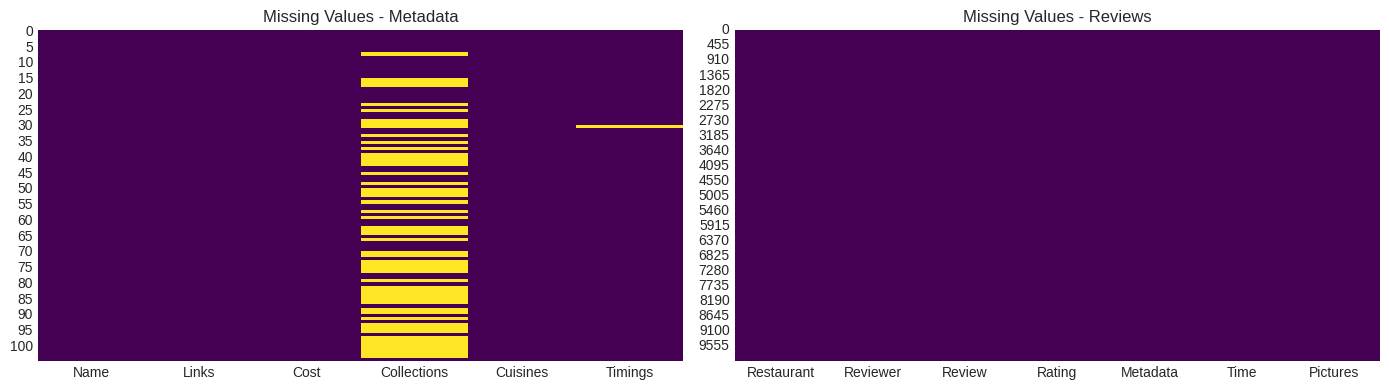

In [10]:
# Visualizing the missing values
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(metadata_df.isnull(), cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values - Metadata')

sns.heatmap(reviews_df.isnull(), cbar=False, cmap='viridis', ax=axes[1])
axes[1].set_title('Missing Values - Reviews')

plt.tight_layout()
plt.show()

### What did you know about your dataset?

We are working with two related datasets covering Zomato restaurants in Hyderabad:

- **Metadata dataset**: 105 restaurants x 6 columns (`Name`, `Links`, `Cost`, `Collections`, `Cuisines`, `Timings`). `Collections` (curated tag lists like "Top-Rated", "Great Buffets") is missing for 54 of 105 restaurants (~51%) - likely because not every restaurant is featured in a Zomato collection, so this is probably a genuine "not tagged" rather than a data error. `Timings` is missing for 1 restaurant. `Cost` is stored as text with thousand-separator commas (e.g. "1,300") and will need numeric conversion.
- **Reviews dataset**: 10,000 reviews x 7 columns (`Restaurant`, `Reviewer`, `Review`, `Rating`, `Metadata`, `Time`, `Pictures`). `Reviewer`, `Review`, `Rating`, `Metadata`, and `Time` are all missing together in exactly 38 rows - meaning these are 38 essentially blank review records (only `Restaurant` and `Pictures`=0 populated) that should be dropped rather than imputed. There are also 36 fully duplicated rows in the reviews data. Only 100 of the 105 restaurants in the metadata actually have reviews in the reviews dataset - 5 restaurants have zero reviews.

Both datasets will be cleaned (Cost converted to numeric, blank/duplicate review rows dropped, Rating standardized) and then merged on restaurant name for the EDA and hypothesis-testing sections, while the review text and rating remain the core inputs for the NLP/ML sentiment classification task.

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
print('Metadata columns :', metadata_df.columns.tolist())
print('Reviews  columns :', reviews_df.columns.tolist())

Metadata columns : ['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings']
Reviews  columns : ['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures']


In [12]:
# Dataset Describe (numerical + categorical summary)
print('--- Metadata describe ---')
display(metadata_df.describe(include='all'))
print('--- Reviews describe ---')
display(reviews_df.describe(include='all'))

--- Metadata describe ---


,Name,Links,Cost,Collections,Cuisines,Timings
count,105,105,105,51,105,104
unique,105,105,29,42,92,77
top,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,500,Food Hygiene Rated Restaurants in Hyderabad,"North Indian, Chinese",11 AM to 11 PM
freq,1,1,13,4,4,6


--- Reviews describe ---


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
count,10000,9962,9955,9962,9962,9962,10000.000000
unique,100,7446,9364,10,2477,9782,NaN
top,Beyond Flavours,Ankita,good,5,1 Review,5/5/2019 22:39,NaN
freq,100,13,237,3832,919,3,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.748600
std,NaN,NaN,NaN,NaN,NaN,NaN,2.570381
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


### Variables Description

**Metadata dataset**
- `Name` - Restaurant name (unique identifier, string)
- `Links` - Zomato page URL for the restaurant
- `Cost` - Approximate cost for two people dining (text with commas, needs numeric cleaning)
- `Collections` - Comma-separated curated Zomato tags/collections the restaurant belongs to (e.g. "Top-Rated", "Great Buffets")
- `Cuisines` - Comma-separated list of cuisines served
- `Timings` - Restaurant operating hours as free text

**Reviews dataset**
- `Restaurant` - Restaurant name (foreign key to Metadata `Name`)
- `Reviewer` - Name of the person who wrote the review
- `Review` - Free-text review content (core NLP input)
- `Rating` - Star rating given, 1-5 (some decimal values like 4.5, and one malformed "Like" value)
- `Metadata` - Text like "3 Reviews, 2 Followers" describing the reviewer's own Zomato activity
- `Time` - Timestamp the review was posted
- `Pictures` - Number of pictures the reviewer attached to the review (numeric)

### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable.
print('--- Metadata unique value counts ---')
for col in metadata_df.columns:
    print(f"{col:15s}: {metadata_df[col].nunique()} unique values")

print()
print('--- Reviews unique value counts ---')
for col in reviews_df.columns:
    print(f"{col:15s}: {reviews_df[col].nunique()} unique values")

print()
print('Raw Rating unique values:', sorted(reviews_df['Rating'].dropna().unique(), key=str))

--- Metadata unique value counts ---
Name           : 105 unique values
Links          : 105 unique values
Cost           : 29 unique values
Collections    : 42 unique values
Cuisines       : 92 unique values
Timings        : 77 unique values

--- Reviews unique value counts ---
Restaurant     : 100 unique values
Reviewer       : 7446 unique values
Review         : 9364 unique values
Rating         : 10 unique values
Metadata       : 2477 unique values
Time           : 9782 unique values
Pictures       : 36 unique values

Raw Rating unique values: ['1', '1.5', '2', '2.5', '3', '3.5', '4', '4.5', '5', 'Like']


## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Write your code to make your dataset analysis ready.

# ---------- 1. Clean Metadata dataset ----------
metadata_clean = metadata_df.copy()

# Cost is stored as text with thousands-comma (e.g. "1,300") -> convert to numeric
metadata_clean['Cost'] = (
    metadata_clean['Cost'].astype(str).str.replace(',', '', regex=False).astype(float)
)

# Collections missing simply means "not featured in any collection" -> explicit label, not an error
metadata_clean['Collections'] = metadata_clean['Collections'].fillna('Not Listed')

# Timings: 1 missing value -> label as Unknown rather than dropping a whole restaurant
metadata_clean['Timings'] = metadata_clean['Timings'].fillna('Unknown')

# Number of cuisines served, useful engineered feature
metadata_clean['Cuisine_Count'] = metadata_clean['Cuisines'].apply(lambda x: len(str(x).split(',')))


# ---------- 2. Clean Reviews dataset ----------
reviews_clean = reviews_df.copy()

# Drop rows that are essentially blank (Reviewer, Review, Rating, Metadata, Time all null together)
reviews_clean = reviews_clean.dropna(subset=['Review', 'Rating']).reset_index(drop=True)

# Drop exact duplicate rows
reviews_clean = reviews_clean.drop_duplicates().reset_index(drop=True)

# Fix the malformed Rating value ('Like' -> treat as missing, then drop since it carries no rating info)
reviews_clean = reviews_clean[reviews_clean['Rating'] != 'Like'].reset_index(drop=True)
reviews_clean['Rating'] = reviews_clean['Rating'].astype(float)

# Parse "X Reviews , Y Followers" out of the Metadata text column into numeric features
def parse_reviewer_metadata(text):
    reviews_count, followers_count = 0, 0
    try:
        parts = str(text).split(',')
        for part in parts:
            part = part.strip().lower()
            num = re.findall(r'\d+', part)
            num = int(num[0]) if num else 0
            if 'review' in part:
                reviews_count = num
            elif 'follower' in part:
                followers_count = num
    except Exception:
        pass
    return pd.Series([reviews_count, followers_count])

reviews_clean[['Reviewer_Review_Count', 'Reviewer_Follower_Count']] = reviews_clean['Metadata'].apply(parse_reviewer_metadata)

# Parse Time to datetime, engineer Year / Month / Day-of-week
reviews_clean['Time'] = pd.to_datetime(reviews_clean['Time'], errors='coerce')
reviews_clean['Review_Year'] = reviews_clean['Time'].dt.year
reviews_clean['Review_Month'] = reviews_clean['Time'].dt.month
reviews_clean['Review_DayOfWeek'] = reviews_clean['Time'].dt.day_name()

# Engineer review length features (word count, character count) - useful for EDA & hypothesis testing
reviews_clean['Review_Word_Count'] = reviews_clean['Review'].apply(lambda x: len(str(x).split()))
reviews_clean['Review_Char_Count'] = reviews_clean['Review'].apply(lambda x: len(str(x)))

# Collapse numeric rating into 3-class sentiment target for the ML task
def rating_to_sentiment(r):
    if r <= 2:
        return 'Negative'
    elif r == 3:
        return 'Neutral'
    else:
        return 'Positive'

reviews_clean['Sentiment'] = reviews_clean['Rating'].apply(rating_to_sentiment)

print(f"Metadata cleaned : {metadata_clean.shape}")
print(f"Reviews  cleaned : {reviews_clean.shape}  (removed {reviews_df.shape[0] - reviews_clean.shape[0]} rows: blanks/dupes/malformed)")
reviews_clean.head()

Metadata cleaned : (105, 7)
Reviews  cleaned : (9954, 15)  (removed 46 rows: blanks/dupes/malformed)


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Reviewer_Review_Count,Reviewer_Follower_Count,Review_Year,Review_Month,Review_DayOfWeek,Review_Word_Count,Review_Char_Count,Sentiment
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,"1 Review , 2 Followers",2019-05-25 15:54:00,0,1,2,2019,5,Saturday,41,222,Positive
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,"3 Reviews , 2 Followers",2019-05-25 14:20:00,0,3,2,2019,5,Saturday,27,144,Positive
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,"2 Reviews , 3 Followers",2019-05-24 22:54:00,0,2,3,2019,5,Friday,31,189,Positive
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,"1 Review , 1 Follower",2019-05-24 22:11:00,0,1,1,2019,5,Friday,28,148,Positive
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,"3 Reviews , 2 Followers",2019-05-24 21:37:00,0,3,2,2019,5,Friday,27,160,Positive


In [15]:
# ---------- 3. Merge datasets ----------
# Left-join reviews onto metadata so we retain restaurant-level attributes (Cost, Cuisines, Collections)
# alongside every review row, for bivariate/multivariate EDA and hypothesis testing.

merged_df = reviews_clean.merge(
    metadata_clean, left_on='Restaurant', right_on='Name', how='left'
)
merged_df = merged_df.drop(columns=['Name'])

print(f"Merged dataset shape: {merged_df.shape}")
print(f"Restaurants with no matching metadata after merge: {merged_df['Cost'].isnull().sum()} review rows")
merged_df.head()

Merged dataset shape: (9954, 21)
Restaurants with no matching metadata after merge: 0 review rows


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Reviewer_Review_Count,Reviewer_Follower_Count,Review_Year,...,Review_DayOfWeek,Review_Word_Count,Review_Char_Count,Sentiment,Links,Cost,Collections,Cuisines,Timings,Cuisine_Count
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,"1 Review , 2 Followers",2019-05-25 15:54:00,0,1,2,2019,...,Saturday,41,222,Positive,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",6
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,"3 Reviews , 2 Followers",2019-05-25 14:20:00,0,3,2,2019,...,Saturday,27,144,Positive,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",6
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,"2 Reviews , 3 Followers",2019-05-24 22:54:00,0,2,3,2019,...,Friday,31,189,Positive,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",6
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,"1 Review , 1 Follower",2019-05-24 22:11:00,0,1,1,2019,...,Friday,28,148,Positive,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",6
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,"3 Reviews , 2 Followers",2019-05-24 21:37:00,0,3,2,2019,...,Friday,27,160,Positive,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",6


### What all manipulations have you done and insights you found?

Key manipulations performed:

1. **Cost cleaning** - stripped thousands-commas and converted `Cost` to numeric (float), enabling it to be used in correlation/statistical analysis.
2. **Missing value handling** - `Collections` nulls (54/105 restaurants) were filled with an explicit "Not Listed" label rather than dropped, since the absence of a collection tag is meaningful, not an error. The 38 fully-blank review rows and 46 total problem rows (blanks + 36 duplicates + 1 malformed "Like" rating) were dropped from Reviews, since imputing free-text review content is not meaningful.
3. **Rating standardization** - removed the single malformed `"Like"` rating value and cast `Rating` to float.
4. **Feature engineering** - extracted `Reviewer_Review_Count` and `Reviewer_Follower_Count` from the free-text `Metadata` column (e.g. "3 Reviews , 2 Followers"); parsed `Time` into `Review_Year`/`Review_Month`/`Review_DayOfWeek`; computed `Review_Word_Count` and `Review_Char_Count` from review text; computed `Cuisine_Count` per restaurant.
5. **Target creation** - collapsed the 1-5 star `Rating` into a 3-class `Sentiment` target (Negative = 1-2 stars, Neutral = 3 stars, Positive = 4-5 stars) for the NLP classification task. The resulting classes are imbalanced: **Positive 63.6% (6,334), Negative 24.4% (2,428), Neutral 12.0% (1,192)** - this imbalance will need to be handled before model training (Section 6).
6. **Merge** - left-joined the cleaned Reviews data onto Metadata by restaurant name, producing a single analysis-ready table of 9,954 review-level rows x 21 columns with zero unmatched rows, used for all EDA, hypothesis testing, and modelling that follows.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### Univariate Analysis

#### Chart - 1 : Sentiment Class Distribution

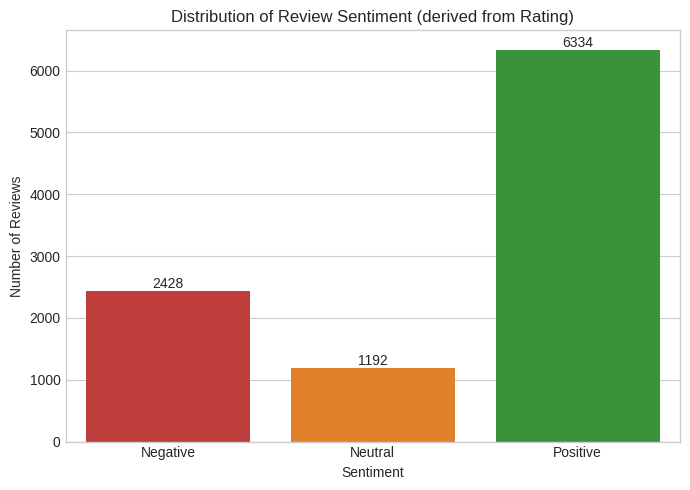

Sentiment
Positive    63.6
Negative    24.4
Neutral     12.0
Name: proportion, dtype: float64

In [16]:
# Chart - 1 visualization code
plt.figure(figsize=(7, 5))
order = ['Negative', 'Neutral', 'Positive']
ax = sns.countplot(data=merged_df, x='Sentiment', order=order,
                    palette={'Negative': '#d62728', 'Neutral': '#ff7f0e', 'Positive': '#2ca02c'})
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.title('Distribution of Review Sentiment (derived from Rating)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

merged_df['Sentiment'].value_counts(normalize=True).mul(100).round(1)

##### 1. Why did you pick the specific chart?

A count/bar chart is the natural choice for the distribution of a single categorical variable (our ML target). It directly shows both absolute counts and relative class sizes at a glance.

##### 2. What is/are the insight(s) found from the chart?

The dataset is **imbalanced towards positive sentiment**: 63.6% of reviews are Positive (6,334), 24.4% are Negative (2,428), and only 12.0% are Neutral (1,192). Positive reviews outnumber Negative by roughly 2.6:1, and Neutral is by far the smallest class.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: it confirms that the overall customer experience being reviewed skews positive, which is good news for the platform/restaurants overall. Negative growth risk: the class imbalance is a genuine modelling risk - a naive classifier could reach ~64% accuracy by always predicting "Positive" while still missing nearly every unhappy customer, which is the exact business-critical group we want to catch. This directly motivates the imbalance-handling step in Section 6.

#### Chart - 2 : Cost for Two - Distribution

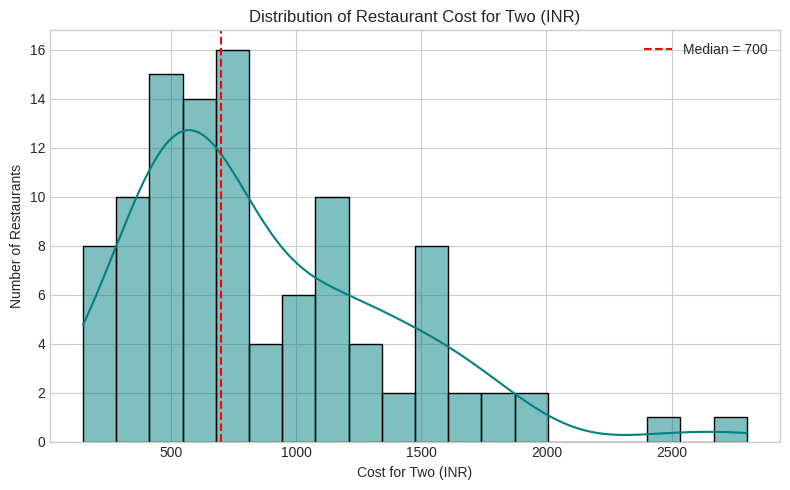

count     105.000000
mean      861.428571
std       510.149730
min       150.000000
25%       500.000000
50%       700.000000
75%      1200.000000
max      2800.000000
Name: Cost, dtype: float64

In [17]:
# Chart - 2 visualization code
plt.figure(figsize=(8, 5))
sns.histplot(metadata_clean['Cost'], bins=20, kde=True, color='teal')
plt.axvline(metadata_clean['Cost'].median(), color='red', linestyle='--', label=f"Median = {metadata_clean['Cost'].median():.0f}")
plt.title('Distribution of Restaurant Cost for Two (INR)')
plt.xlabel('Cost for Two (INR)')
plt.ylabel('Number of Restaurants')
plt.legend()
plt.tight_layout()
plt.show()

metadata_clean['Cost'].describe()

##### 1. Why did you pick the specific chart?

A histogram with KDE overlay is ideal for visualizing the shape (skew, spread, modality) of a single continuous variable like cost.

##### 2. What is/are the insight(s) found from the chart?

Restaurant cost for two ranges from ₹150 to ₹2,800, with a median of ₹700 and mean of ~₹861. The distribution is right-skewed - most restaurants cluster in the ₹300-₹1,200 (budget to mid-range) band, with a long tail of a smaller number of premium restaurants priced above ₹1,500.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: confirms Hyderabad's Zomato listings in this sample are dominated by affordable/mid-range dining, which is useful for the platform to calibrate default price filters and recommendations for the majority of price-sensitive users. No inherent negative-growth signal here, but the long tail of expensive outliers is worth flagging as a separate premium segment rather than averaging it in with budget restaurants.

#### Chart - 3 : Most Common Cuisines

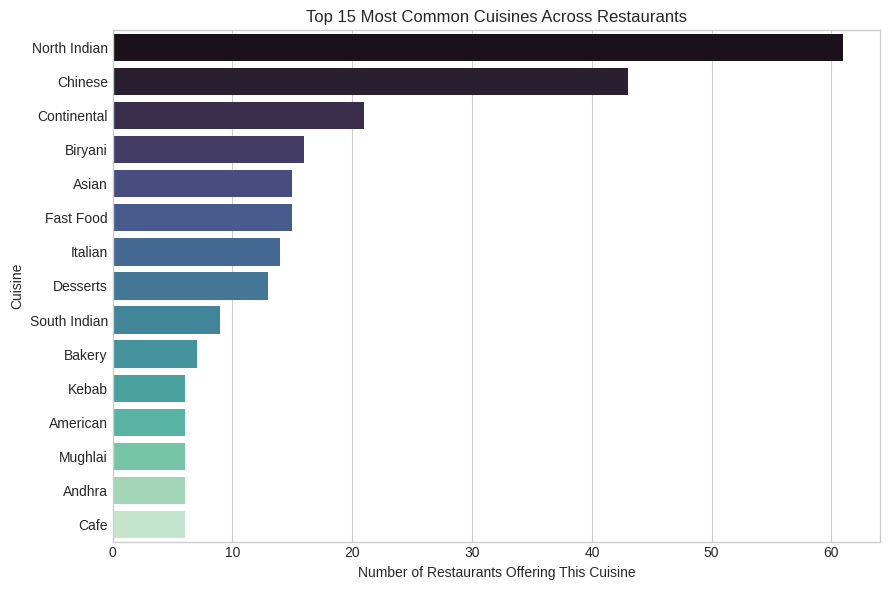

Cuisines
North Indian    61
Chinese         43
Continental     21
Biryani         16
Asian           15
Fast Food       15
Italian         14
Desserts        13
South Indian     9
Bakery           7
Kebab            6
American         6
Mughlai          6
Andhra           6
Cafe             6
Name: count, dtype: int64

In [18]:
# Chart - 3 visualization code
cuisine_series = metadata_clean['Cuisines'].str.split(',').explode().str.strip()
top_cuisines = cuisine_series.value_counts().head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette='mako')
plt.title('Top 15 Most Common Cuisines Across Restaurants')
plt.xlabel('Number of Restaurants Offering This Cuisine')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()

top_cuisines

##### 1. Why did you pick the specific chart?

A horizontal bar chart ranks categorical frequency counts (cuisines) clearly, and horizontal orientation keeps the 15 cuisine labels readable.

##### 2. What is/are the insight(s) found from the chart?

North Indian (61 restaurants) and Chinese (43) dominate the cuisine landscape by a wide margin, followed by Continental (21), Biryani (16), and Asian/Fast Food (15 each). Most other cuisines (South Indian, Bakery, Kebab, American, Mughlai, Andhra, Cafe) each appear in single digits.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: North Indian/Chinese being near-universal "safe" cuisines validates focusing marketing and delivery-logistics investment there. Negative growth risk: cuisines like Andhra and South Indian - which are actually native to the Hyderabad/Telangana region - are comparatively under-represented on the platform relative to pan-Indian cuisines; this is a potential gap for regional-cuisine restaurant acquisition.

#### Chart - 4 : Review Length (Word Count) Distribution

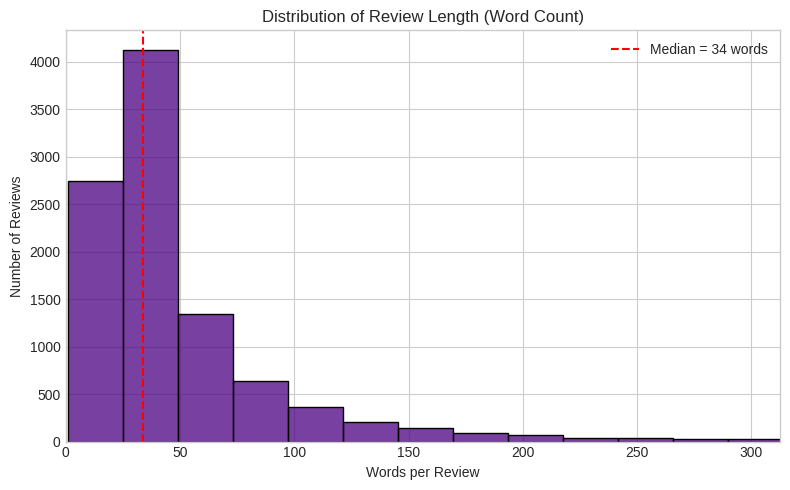

count    9954.000000
mean       50.173297
std        60.786767
min         1.000000
25%        24.000000
50%        34.000000
75%        58.000000
max       964.000000
Name: Review_Word_Count, dtype: float64

In [19]:
# Chart - 4 visualization code
plt.figure(figsize=(8, 5))
sns.histplot(merged_df['Review_Word_Count'], bins=40, color='indigo')
plt.axvline(merged_df['Review_Word_Count'].median(), color='red', linestyle='--',
            label=f"Median = {merged_df['Review_Word_Count'].median():.0f} words")
plt.xlim(0, merged_df['Review_Word_Count'].quantile(0.99))
plt.title('Distribution of Review Length (Word Count)')
plt.xlabel('Words per Review')
plt.ylabel('Number of Reviews')
plt.legend()
plt.tight_layout()
plt.show()

merged_df['Review_Word_Count'].describe()

##### 1. Why did you pick the specific chart?

A histogram shows the shape of the review-length distribution (likely right-skewed, since most reviews are short and a few are very long), which is important context for NLP preprocessing decisions later.

##### 2. What is/are the insight(s) found from the chart?

Review length is heavily right-skewed: the median review is only 34 words, with 75% of reviews under 58 words, but the distribution has a long tail extending to 964 words. Most customers write short reviews; only a minority write detailed, long-form feedback.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: knowing most reviews are short (median 34 words) means the NLP pipeline and TF-IDF vectorization don't need to handle extremely long documents in the common case, which keeps the model efficient. It also suggests that when a customer does write a long review, it may signal an unusually strong (positive or negative) experience worth reading directly - useful for prioritizing manual review of outlier-length feedback.

#### Chart - 5 : Top 15 Restaurants by Number of Reviews

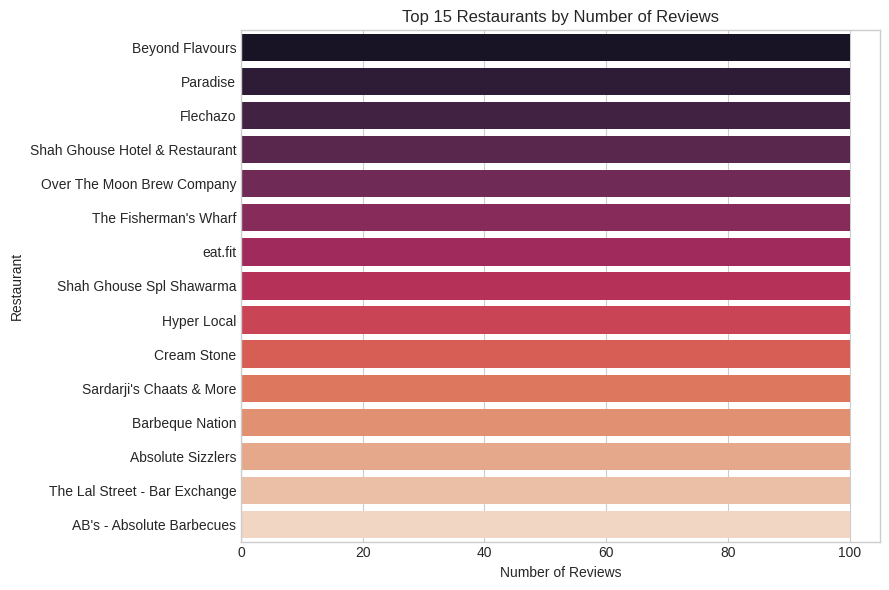

Restaurant
Beyond Flavours                   100
Paradise                          100
Flechazo                          100
Shah Ghouse Hotel & Restaurant    100
Over The Moon Brew Company        100
The Fisherman's Wharf             100
eat.fit                           100
Shah Ghouse Spl Shawarma          100
Hyper Local                       100
Cream Stone                       100
Sardarji's Chaats & More          100
Barbeque Nation                   100
Absolute Sizzlers                 100
The Lal Street - Bar Exchange     100
AB's - Absolute Barbecues         100
Name: count, dtype: int64

In [20]:
# Chart - 5 visualization code
top_restaurants = merged_df['Restaurant'].value_counts().head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_restaurants.values, y=top_restaurants.index, palette='rocket')
plt.title('Top 15 Restaurants by Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Restaurant')
plt.tight_layout()
plt.show()

top_restaurants

##### 1. Why did you pick the specific chart?

A ranked bar chart is the clearest way to compare review counts (a single numeric measure) across a categorical field (restaurant name).

##### 2. What is/are the insight(s) found from the chart?

Every restaurant in the reviews dataset has **exactly 100 reviews** (15 shown, but this holds across all 100 restaurants with reviews - 100 restaurants x 100 reviews = 10,000 rows, matching the original file size). This means the review data was uniformly sampled per restaurant rather than reflecting true organic review volume.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is an important caveat for business interpretation, not really a "positive/negative growth" insight: since every restaurant has the same review count by construction (a fixed sample of 100), review *count* itself cannot be used as a genuine popularity signal in this dataset - only review *content and rating* are informative for restaurant comparison. Treating review count as a popularity metric here would be a modelling mistake.

### Bivariate Analysis

#### Chart - 6 : Cost vs Sentiment (Numerical - Categorical)

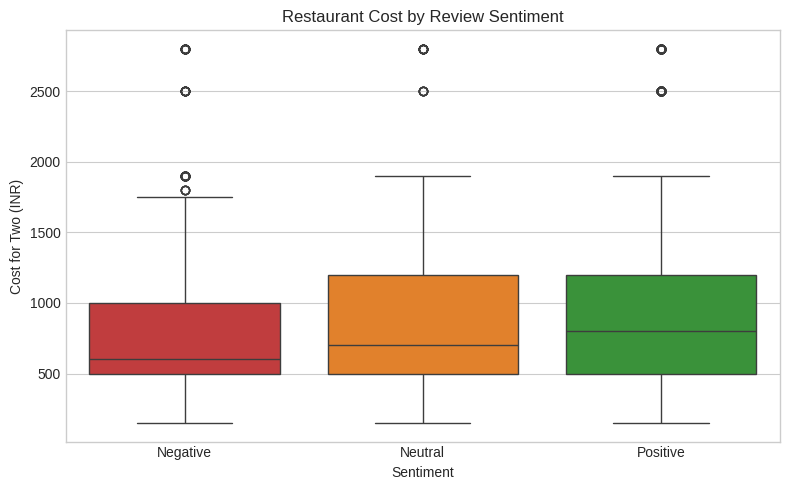

Sentiment
Negative    600.0
Neutral     700.0
Positive    800.0
Name: Cost, dtype: float64

In [21]:
# Chart - 6 visualization code
plt.figure(figsize=(8, 5))
order = ['Negative', 'Neutral', 'Positive']
sns.boxplot(data=merged_df, x='Sentiment', y='Cost', order=order,
            palette={'Negative': '#d62728', 'Neutral': '#ff7f0e', 'Positive': '#2ca02c'})
plt.title('Restaurant Cost by Review Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Cost for Two (INR)')
plt.tight_layout()
plt.show()

merged_df.groupby('Sentiment')['Cost'].median()

##### 1. Why did you pick the specific chart?

A box plot compares the distribution of a numerical variable (Cost) across categorical groups (Sentiment), showing median, spread, and outliers together - ideal for a Num-Cat relationship.

##### 2. What is/are the insight(s) found from the chart?

Median cost climbs steadily with sentiment: ₹600 for Negative reviews, ₹700 for Neutral, and ₹800 for Positive reviews. Pricier restaurants tend to skew toward more positive reviews, though the boxes overlap substantially, so cost alone is a weak, not decisive, predictor of sentiment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: there's a real, if modest, signal that higher-cost restaurants earn more favorable sentiment on average - useful context for restaurant partners considering price positioning. Negative growth risk: since the boxes overlap heavily, cheap restaurants clearly can and do earn Positive sentiment too, so cost should not be over-weighted as a rating driver; using it as a sole explanation risks missing service/food/quality factors visible only in the text.

#### Chart - 7 : Restaurant Average Rating vs Cost (Numerical - Numerical)

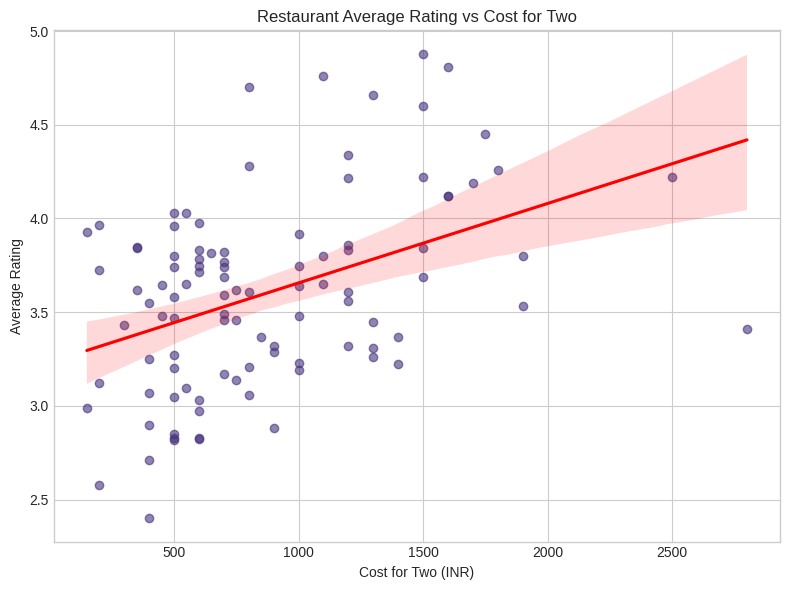

Pearson correlation (Cost vs Avg Rating): 0.422


In [22]:
# Chart - 7 visualization code
restaurant_avg = merged_df.groupby('Restaurant').agg(
    Avg_Rating=('Rating', 'mean'),
    Cost=('Cost', 'first')
).reset_index()

plt.figure(figsize=(8, 6))
sns.regplot(data=restaurant_avg, x='Cost', y='Avg_Rating', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Restaurant Average Rating vs Cost for Two')
plt.xlabel('Cost for Two (INR)')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

print('Pearson correlation (Cost vs Avg Rating):', round(restaurant_avg['Cost'].corr(restaurant_avg['Avg_Rating']), 3))

##### 1. Why did you pick the specific chart?

A scatter plot with a regression trendline is the standard way to visualize the relationship between two continuous numeric variables and estimate the direction/strength of any linear association.

##### 2. What is/are the insight(s) found from the chart?

At the restaurant level, Cost and Average Rating show a **moderate positive correlation (Pearson r = 0.42)**. The regression trendline slopes upward, but there is meaningful scatter - several low-cost restaurants achieve high average ratings, and a few expensive ones underperform.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: confirms a genuine, moderate "you get what you pay for" pattern platform-wide, which restaurants can use as a rough pricing-quality benchmark. Negative growth risk: r=0.42 is far from a strong correlation, meaning cost explains under 20% of the variance in rating (r² ≈ 0.18) - a restaurant cannot assume raising prices will improve ratings, and low performers at high price points are exposed as clear underperformers relative to peers.

#### Chart - 8 : Review Length vs Sentiment (Numerical - Categorical)

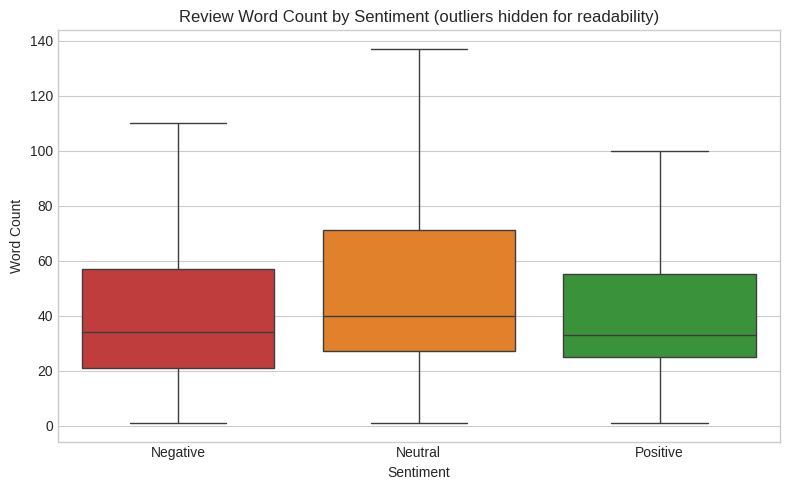

Sentiment
Negative    34.0
Neutral     40.0
Positive    33.0
Name: Review_Word_Count, dtype: float64

In [23]:
# Chart - 8 visualization code
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged_df, x='Sentiment', y='Review_Word_Count', order=order,
            palette={'Negative': '#d62728', 'Neutral': '#ff7f0e', 'Positive': '#2ca02c'}, showfliers=False)
plt.title('Review Word Count by Sentiment (outliers hidden for readability)')
plt.xlabel('Sentiment')
plt.ylabel('Word Count')
plt.tight_layout()
plt.show()

merged_df.groupby('Sentiment')['Review_Word_Count'].median()

##### 1. Why did you pick the specific chart?

Box plots again suit comparing a numeric distribution (review length) across the categorical sentiment classes, and are robust to the heavy right-skew seen in Chart 4.

##### 2. What is/are the insight(s) found from the chart?

Median word count is fairly similar across sentiment classes (33-40 words), with Neutral reviews running slightly longer (median 40) than both Negative (34) and Positive (33) reviews.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: since sentiment classes don't differ dramatically in typical length, review length by itself is not a strong standalone signal for sentiment - which is a useful negative finding, telling us the ML model genuinely needs to read the text content (not just count words) to classify sentiment well. No major negative-growth implication here; it's primarily a modelling-design insight.

#### Chart - 9 : Pictures Attached vs Sentiment (Numerical - Categorical)

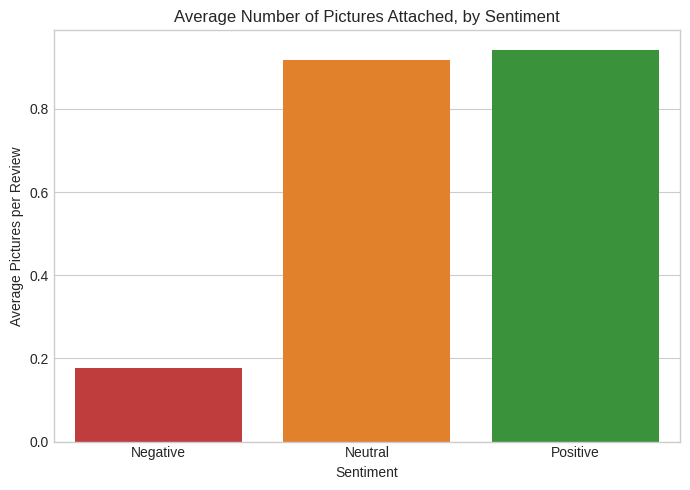

Sentiment
Negative    0.176277
Neutral     0.916946
Positive    0.941585
Name: Pictures, dtype: float64

In [24]:
# Chart - 9 visualization code
pic_sentiment = merged_df.groupby('Sentiment')['Pictures'].mean().reindex(order)

plt.figure(figsize=(7, 5))
sns.barplot(x=pic_sentiment.index, y=pic_sentiment.values,
            palette={'Negative': '#d62728', 'Neutral': '#ff7f0e', 'Positive': '#2ca02c'})
plt.title('Average Number of Pictures Attached, by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Pictures per Review')
plt.tight_layout()
plt.show()

pic_sentiment

##### 1. Why did you pick the specific chart?

A bar chart of group means is a simple, direct way to compare a numeric behaviour (pictures attached) across the three sentiment categories.

##### 2. What is/are the insight(s) found from the chart?

A sharp gap emerges: Positive reviews average **0.94 pictures**, Neutral **0.92**, but Negative reviews average only **0.18 pictures** - roughly 5x fewer photos than the other two classes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: customers overwhelmingly photograph food/venues when the experience is good or neutral, so picture-attached reviews are a strong, easy-to-compute proxy signal the platform could use to fast-track "showcase-worthy" content for marketing. Negative growth risk: conversely, an almost-photo-free review is a fairly reliable early flag for a negative experience - this could be built into a lightweight triage rule (reviews with 0 pictures + low/no rating get prioritized for restaurant-partner follow-up) even before running full NLP.

#### Chart - 10 : Number of Cuisines vs Cost (Numerical - Numerical)

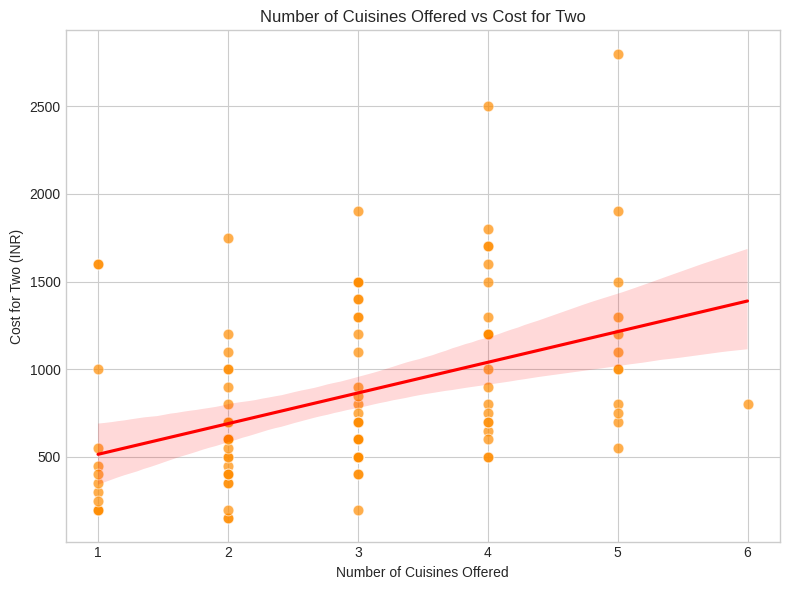

Pearson correlation (Cuisine Count vs Cost): 0.414


In [25]:
# Chart - 10 visualization code
plt.figure(figsize=(8, 6))
sns.scatterplot(data=metadata_clean, x='Cuisine_Count', y='Cost', alpha=0.7, s=60, color='darkorange')
sns.regplot(data=metadata_clean, x='Cuisine_Count', y='Cost', scatter=False, color='red')
plt.title('Number of Cuisines Offered vs Cost for Two')
plt.xlabel('Number of Cuisines Offered')
plt.ylabel('Cost for Two (INR)')
plt.tight_layout()
plt.show()

print('Pearson correlation (Cuisine Count vs Cost):', round(metadata_clean['Cuisine_Count'].corr(metadata_clean['Cost']), 3))

##### 1. Why did you pick the specific chart?

Another scatter plot with trendline, appropriate for testing whether menu breadth (cuisine count) is associated with pricing (both continuous numeric variables).

##### 2. What is/are the insight(s) found from the chart?

Cuisine count and Cost show a **moderate positive correlation (r = 0.41)** - restaurants offering more diverse cuisines tend to charge somewhat more, though again with considerable scatter around the trend.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: suggests restaurants can justify a modest price premium by broadening their cuisine offering (multi-cuisine restaurants trend pricier), useful positioning advice for restaurant partners. No strong negative-growth signal, though the moderate (not strong) correlation means simply adding cuisines is not guaranteed to lift price point - execution quality still matters more.

#### Chart - 11 : Review Volume by Day of Week, split by Sentiment (Categorical - Categorical)

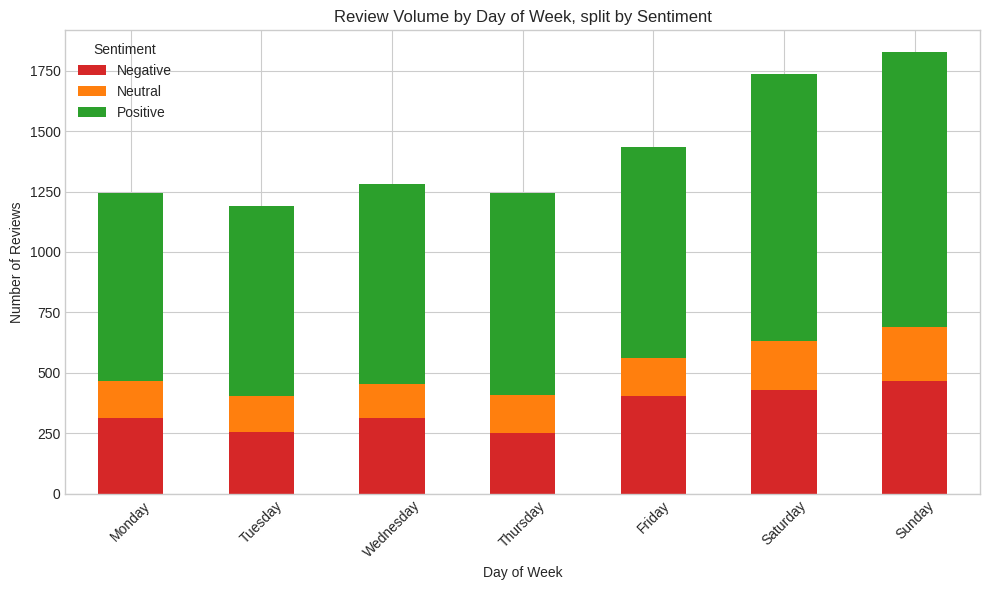

Sentiment,Negative,Neutral,Positive
Review_DayOfWeek,,,
Monday,312,153,779
Tuesday,255,150,787
Wednesday,312,142,828
Thursday,252,157,834
Friday,403,160,869
Saturday,429,205,1102
Sunday,465,225,1135


In [26]:
# Chart - 11 visualization code
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sentiment = pd.crosstab(merged_df['Review_DayOfWeek'], merged_df['Sentiment']).reindex(day_order)

day_sentiment[order].plot(kind='bar', stacked=True, figsize=(10, 6),
                           color=['#d62728', '#ff7f0e', '#2ca02c'])
plt.title('Review Volume by Day of Week, split by Sentiment')
plt.xlabel('Day of Week')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

day_sentiment

##### 1. Why did you pick the specific chart?

A stacked bar chart compares two categorical variables (day of week and sentiment) at once, showing both total review volume per day and the sentiment composition within each day.

##### 2. What is/are the insight(s) found from the chart?

Review volume rises steadily through the week and peaks on **Saturday (1,736 reviews) and Sunday (1,825 reviews)** - both far above weekday counts (~1,150-1,290). The sentiment mix stays broadly similar across all days (roughly 60-65% Positive, ~22-27% Negative, ~11-12% Neutral), so the day of week shifts volume but not sentiment composition much.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: weekend dining drives ~50% more review volume than an average weekday, confirming weekends are the highest-stakes period operationally - restaurants and Zomato support/ops teams should staff and monitor most heavily on Saturday/Sunday. Since sentiment ratio doesn't worsen on weekends despite the volume surge, there's no evidence weekend crowding is currently hurting the customer experience - a genuinely positive operational finding worth monitoring going forward.

### Multivariate Analysis

#### Chart - 12 : Sentiment Composition for Top 10 Most Expensive vs Cheapest Restaurants

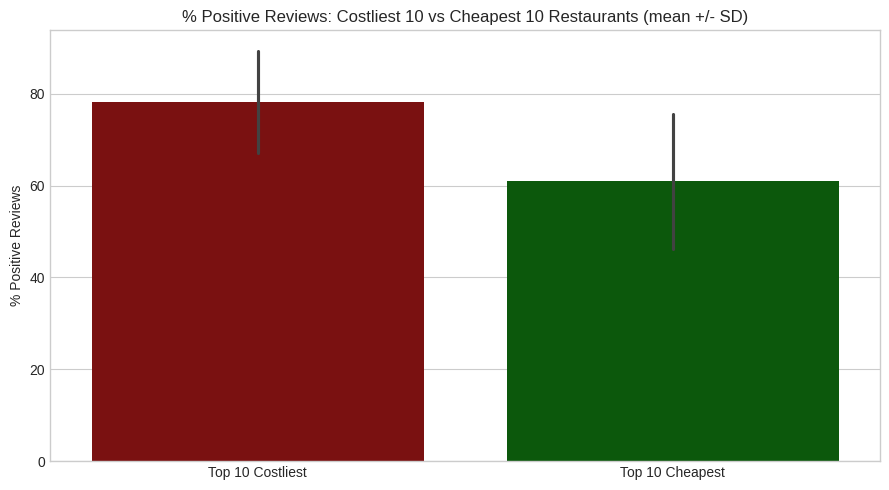

,Positive_Pct,Negative_Pct,Cost
Group,,,
Top 10 Cheapest,60.9,28.6,245.0
Top 10 Costliest,78.3,11.6,1915.0


In [27]:
# Chart - 12 visualization code
restaurant_stats = merged_df.groupby('Restaurant').agg(
    Cost=('Cost', 'first'),
    Positive_Pct=('Sentiment', lambda x: (x == 'Positive').mean() * 100),
    Negative_Pct=('Sentiment', lambda x: (x == 'Negative').mean() * 100)
).reset_index()

top_expensive = restaurant_stats.nlargest(10, 'Cost').assign(Group='Top 10 Costliest')
top_cheap = restaurant_stats.nsmallest(10, 'Cost').assign(Group='Top 10 Cheapest')
combined = pd.concat([top_expensive, top_cheap])

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=combined, x='Group', y='Positive_Pct', hue='Group', legend=False,
            palette=['#8B0000', '#006400'], ax=ax, errorbar='sd')
ax.set_title('% Positive Reviews: Costliest 10 vs Cheapest 10 Restaurants (mean +/- SD)')
ax.set_ylabel('% Positive Reviews')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

combined.groupby('Group')[['Positive_Pct', 'Negative_Pct', 'Cost']].mean().round(1)

##### 1. Why did you pick the specific chart?

This combines three variables at once - cost tier (grouping), % positive sentiment, and % negative sentiment - letting us compare sentiment quality across the two price extremes simultaneously (a multivariate view).

##### 2. What is/are the insight(s) found from the chart?

The Top 10 costliest restaurants (avg cost ₹1,915) earn 78.3% Positive and only 11.6% Negative reviews, compared to the Top 10 cheapest (avg cost ₹245) earning 60.9% Positive and 28.6% Negative - a substantially wider gap than the overall correlation (r=0.42) alone suggested, since this compares the true extremes rather than the full range.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: at the extremes, premium restaurants are clearly delivering a meaningfully better customer experience (2.5x lower negative rate), which validates that premium positioning does typically correlate with quality of execution, not just price. Negative growth risk: the cheapest restaurant tier carries a 28.6% negative rate - more than 1 in 4 reviews - which is a real churn/reputation risk for budget-tier restaurant partners; this segment should be prioritized for the kind of automated sentiment monitoring this project builds.

#### Chart - 13 - Correlation Heatmap

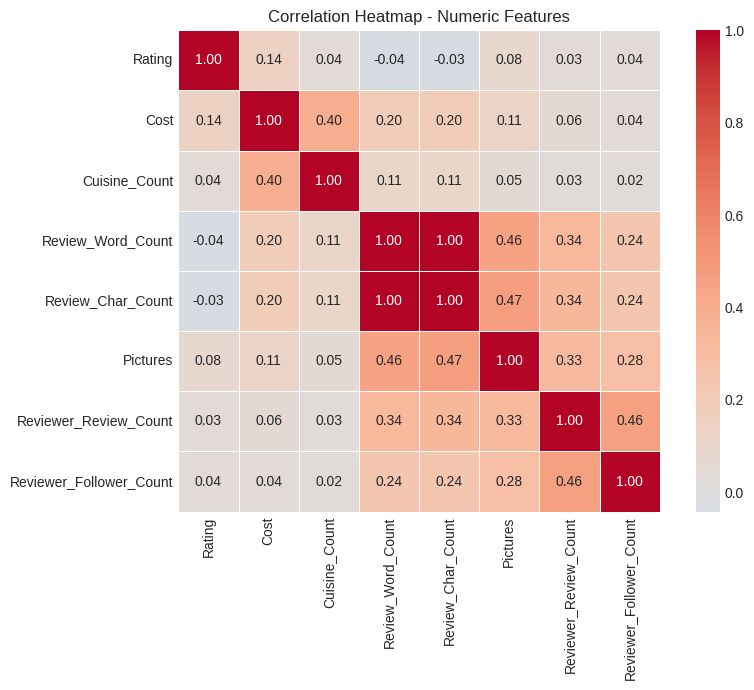

In [28]:
# Correlation Heatmap visualization code
numeric_cols = ['Rating', 'Cost', 'Cuisine_Count', 'Review_Word_Count', 'Review_Char_Count',
                'Pictures', 'Reviewer_Review_Count', 'Reviewer_Follower_Count']
corr_matrix = merged_df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to inspect pairwise linear relationships across many numeric variables simultaneously, quickly flagging strong/weak or redundant relationships (e.g., multicollinearity risk) before modelling.

##### 2. What is/are the insight(s) found from the chart?

`Review_Word_Count` and `Review_Char_Count` are (expectedly) almost perfectly correlated (1.00) and will be redundant as model features - only one should be kept. `Pictures` correlates moderately with `Review_Word_Count` (0.46-0.47) and with `Reviewer_Review_Count`/`Reviewer_Follower_Count` (0.28-0.33), suggesting more "engaged" reviewers write longer reviews and attach more photos. Notably, **`Rating` itself has weak correlation with every other numeric feature** (all |r| <= 0.14), confirming that none of the numeric metadata alone predicts rating - the review text is where the real signal lives.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: this heatmap justifies the project's core design decision - since no numeric feature meaningfully predicts Rating/Sentiment, building an NLP text-classification model (rather than a simple numeric regression) is the right approach, and this evidence should be cited to stakeholders questioning why we need the more complex NLP pipeline. Negative growth risk / caution: the near-perfect Word Count vs Char Count correlation is a multicollinearity trap - including both as model features would add noise without new information, so only one should be retained during feature selection.

#### Chart - 14 - Pair Plot

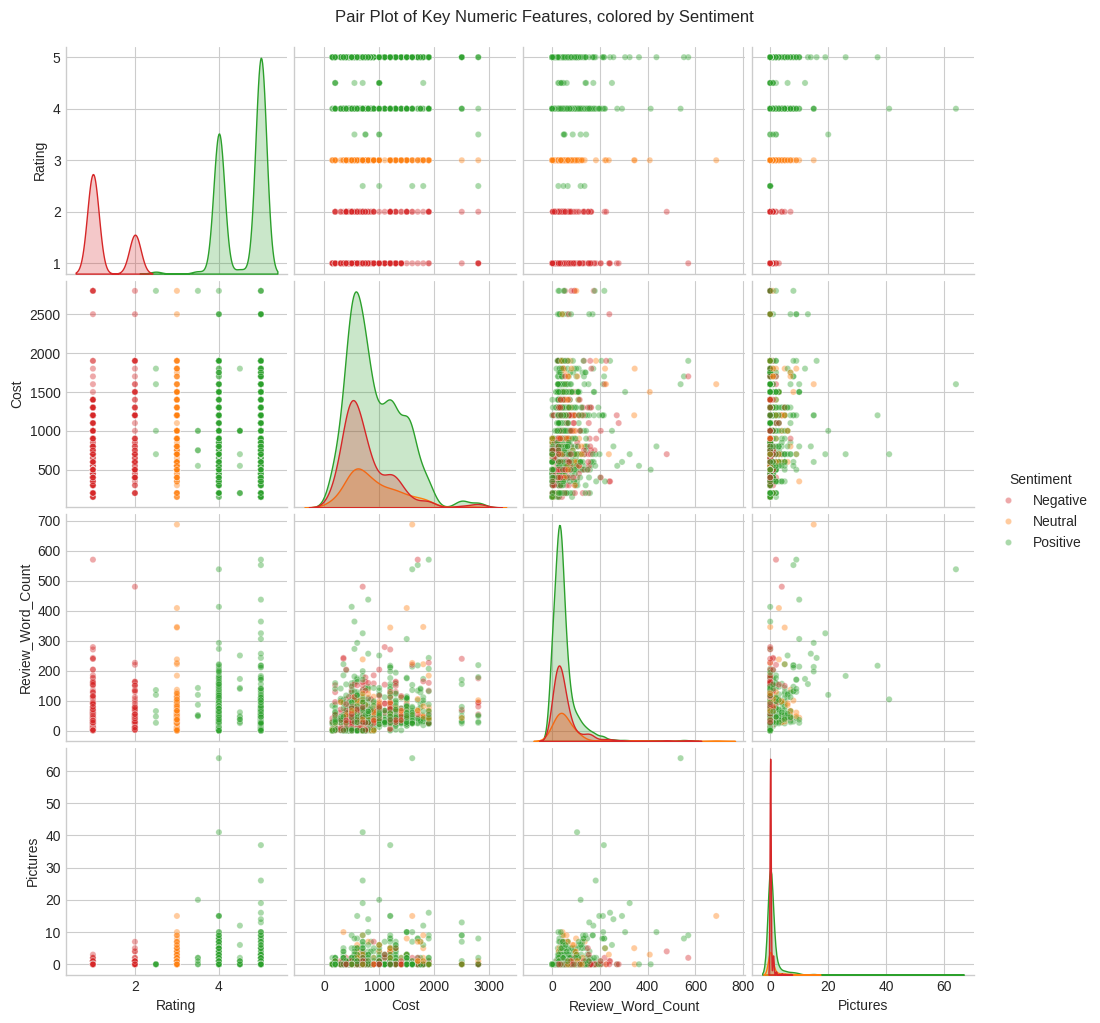

In [29]:
# Pair Plot visualization code
pairplot_cols = ['Rating', 'Cost', 'Review_Word_Count', 'Pictures', 'Sentiment']
pp_sample = merged_df[pairplot_cols].sample(1500, random_state=42)  # sample for rendering speed

sns.pairplot(pp_sample, hue='Sentiment', hue_order=order,
             palette={'Negative': '#d62728', 'Neutral': '#ff7f0e', 'Positive': '#2ca02c'},
             plot_kws={'alpha': 0.4, 's': 20}, diag_kind='kde')
plt.suptitle('Pair Plot of Key Numeric Features, colored by Sentiment', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot shows every pairwise scatter relationship among several numeric features at once, split by sentiment class, revealing multivariate structure and separability that individual bivariate charts might miss.

##### 2. What is/are the insight(s) found from the chart?

Visually, Positive (green) and Negative (red) points overlap heavily across Rating, Cost, Word Count, and Pictures - there is no clean geometric separation between sentiment classes using these numeric features alone. The diagonal KDEs confirm each class's Rating distribution is naturally distinct (by construction, since Sentiment is derived from Rating), but the other numeric features show substantial overlap between classes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: this is a useful modelling insight - it further confirms text content (not numeric metadata) must carry the discriminative signal for the classifier, reinforcing the NLP-first approach and setting realistic expectations that a model using only numeric features would perform poorly. No direct positive/negative growth implication for the business, but it is an important caution against over-simplified "numbers-only" dashboards that claim to predict sentiment without reading the review text.

#### Chart - 15 : Word Clouds - Positive vs Negative Review Text

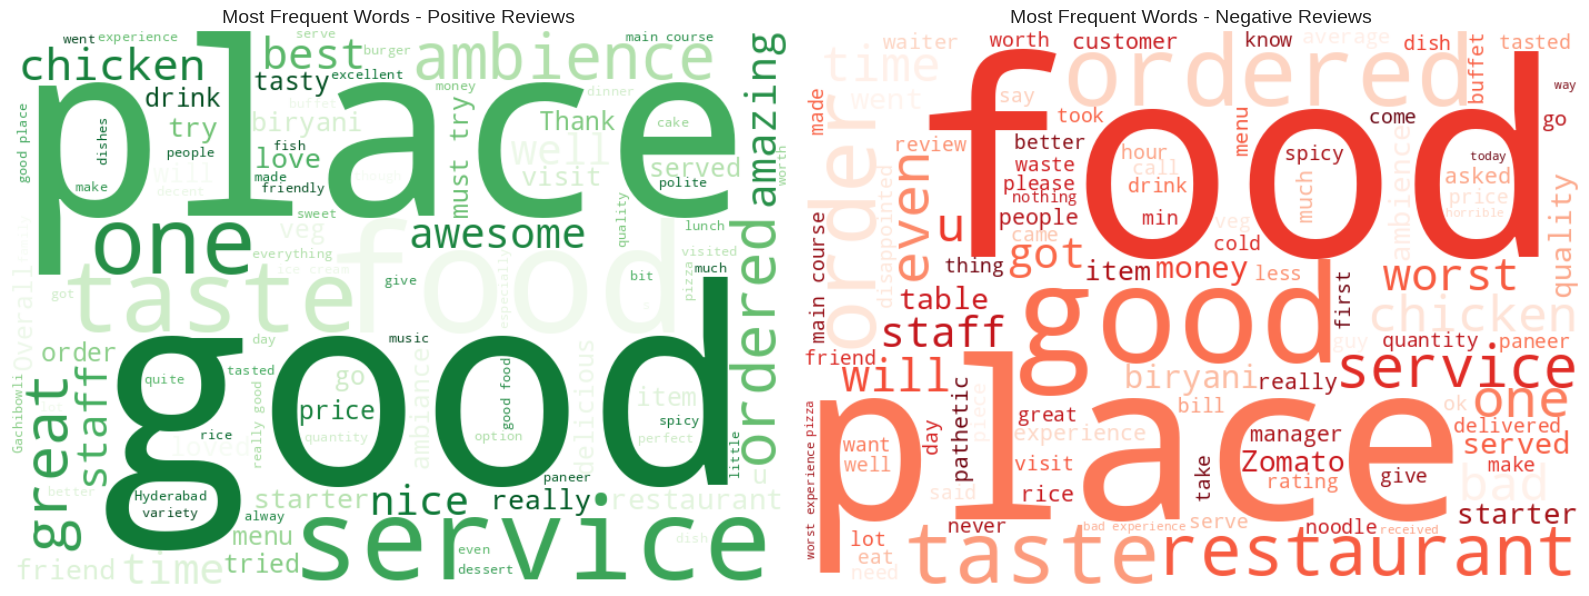

In [30]:
# Chart - 15 visualization code
positive_text = ' '.join(merged_df.loc[merged_df['Sentiment'] == 'Positive', 'Review'].astype(str).sample(3000, random_state=42))
negative_text = ' '.join(merged_df.loc[merged_df['Sentiment'] == 'Negative', 'Review'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wc_pos = WordCloud(width=700, height=500, background_color='white', colormap='Greens', max_words=100).generate(positive_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Frequent Words - Positive Reviews', fontsize=14)

wc_neg = WordCloud(width=700, height=500, background_color='white', colormap='Reds', max_words=100).generate(negative_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Frequent Words - Negative Reviews', fontsize=14)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A word cloud is a purpose-built visualization for text data, instantly surfacing the most frequent terms in a corpus and letting us contrast vocabulary between Positive and Negative reviews - a multivariate view combining text content with the sentiment label.

##### 2. What is/are the insight(s) found from the chart?

Positive reviews are dominated by warm, evaluative words - "good", "place", "amazing", "best", "excellent", "delicious", "service", "ambience", "taste", "friendly staff". Negative reviews center on operational/service failure language - "worst", "waste", "disappointed", "bad", "pathetic", "manager", "waiter", "bill", "horrible" - alongside food-service nouns like "order", "food", "restaurant", "chicken", "biryani" which appear in both (they're just topic words, not sentiment words).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: the clear separation in *sentiment-bearing* vocabulary (independent of food-topic words) is strong evidence that a TF-IDF/text-based classifier should perform well, and it also gives the business a ready-made "negative-signal keyword list" (waste, disappointed, pathetic, worst, horrible, manager, waiter, bill) that could power a simple real-time alert rule even before the full ML model is deployed. Negative growth risk: the frequent appearance of "manager" and "waiter" in negative reviews suggests **service/staff interactions**, not just food quality, are a recurring complaint driver - actionable for restaurant partners to address through staff training rather than menu changes.

#### Chart - 16 : Positive Sentiment Rate by Cost Bucket, split by Top Cuisines

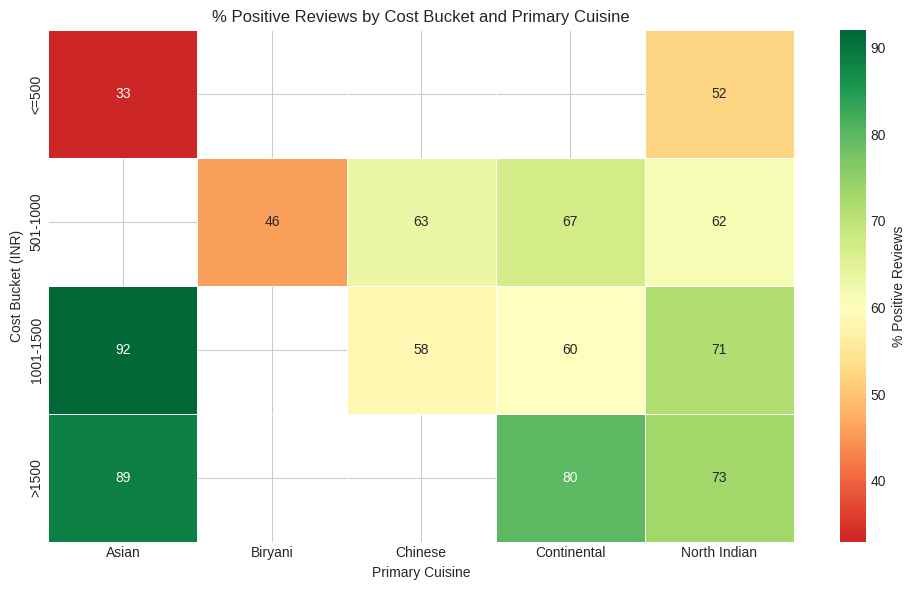

In [31]:
# Chart - 16 visualization code
metadata_clean['Cost_Bucket'] = pd.cut(metadata_clean['Cost'], bins=[0, 500, 1000, 1500, 3000],
                                        labels=['<=500', '501-1000', '1001-1500', '>1500'])

merged_df2 = merged_df.merge(metadata_clean[['Name', 'Cost_Bucket']], left_on='Restaurant', right_on='Name', how='left')

top5_cuisines = cuisine_series.value_counts().head(5).index.tolist()
merged_df2['Primary_Cuisine'] = merged_df2['Cuisines'].apply(
    lambda x: next((c for c in top5_cuisines if c in str(x)), 'Other')
)

pivot = merged_df2[merged_df2['Primary_Cuisine'] != 'Other'].groupby(
    ['Cost_Bucket', 'Primary_Cuisine'], observed=True
)['Sentiment'].apply(lambda x: (x == 'Positive').mean() * 100).unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=60, linewidths=0.5, cbar_kws={'label': '% Positive Reviews'})
plt.title('% Positive Reviews by Cost Bucket and Primary Cuisine')
plt.xlabel('Primary Cuisine')
plt.ylabel('Cost Bucket (INR)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap over a pivoted cost-bucket x cuisine grid packs three dimensions (cost tier, cuisine, and % positive sentiment as color intensity) into one multivariate view, revealing interaction effects a single bivariate chart cannot show.

##### 2. What is/are the insight(s) found from the chart?

Positive sentiment rate rises with cost within nearly every cuisine: North Indian goes from 52.4% (<=500) up to 73.0% (>1500); Continental from 67.0% (501-1000) up to 80.0% (>1500); Asian jumps sharply from 33.0% (<=500) to 89-92% in higher brackets. Chinese, however, is more mixed - 63.0% in the 501-1000 bracket, dipping to 58.5% in 1001-1500, showing the cost-quality relationship isn't perfectly uniform across all cuisines.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: this confirms the cost-sentiment relationship (Chart 6/7) holds broadly across most individual cuisines too, not just in aggregate - giving restaurant partners cuisine-specific pricing/quality benchmarks to target. Negative growth risk: budget Asian-cuisine restaurants (<=500) stand out with a notably low 33% positive rate - well below every other cell in the grid - flagging this specific price-cuisine combination as a priority segment for quality investigation and partner support, since it is significantly underperforming its peers at similar price points in other cuisines.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the EDA above (Charts 6, 7, 9, 12, and 16 in particular), three hypotheses stand out as worth formal statistical testing rather than relying on visual impression alone:

1. Restaurant **cost** is associated with **average rating**.
2. **Review length** (word count) differs by **sentiment class**.
3. The number of **pictures** attached is associated with **rating**.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0 (Null):** There is no significant linear correlation between a restaurant's cost for two and its average rating (population correlation ρ = 0).
**H1 (Alternate):** There is a significant linear correlation between a restaurant's cost for two and its average rating (ρ ≠ 0).

#### 2. Perform an appropriate statistical test.

In [32]:
# Perform Statistical Test to obtain P-Value

# Restaurant-level average rating vs cost (as built in Chart 7)
restaurant_avg = merged_df.groupby('Restaurant').agg(
    Avg_Rating=('Rating', 'mean'),
    Cost=('Cost', 'first')
).dropna()

corr_coef, p_value = stats.pearsonr(restaurant_avg['Cost'], restaurant_avg['Avg_Rating'])

alpha = 0.05
print(f"Pearson correlation coefficient : {corr_coef:.4f}")
print(f"P-value                         : {p_value:.6f}")

if p_value < alpha:
    print(f"\nResult: p-value ({p_value:.6f}) < alpha (0.05) -> Reject the Null Hypothesis (H0).")
    print("There IS a statistically significant correlation between Cost and Average Rating.")
else:
    print(f"\nResult: p-value ({p_value:.6f}) >= alpha (0.05) -> Fail to reject the Null Hypothesis (H0).")

Pearson correlation coefficient : 0.4223
P-value                         : 0.000012

Result: p-value (0.000012) < alpha (0.05) -> Reject the Null Hypothesis (H0).
There IS a statistically significant correlation between Cost and Average Rating.


##### Which statistical test have you done to obtain P-Value?

**Pearson correlation test** (`scipy.stats.pearsonr`), which tests whether the linear correlation coefficient between two continuous numeric variables (Cost and Average Rating) is significantly different from zero.

##### Why did you choose the specific statistical test?

Both variables (`Cost` and `Average Rating`) are continuous numeric measurements, and Chart 7 showed a roughly linear relationship between them. Pearson's test is the standard, most statistically powerful choice for testing linear association between two continuous variables when the relationship is approximately linear, and it directly outputs both an effect-size (r) and a p-value for significance testing.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0 (Null):** The mean review word count is the same for Positive and Negative sentiment reviews.
**H1 (Alternate):** The mean review word count differs between Positive and Negative sentiment reviews.

#### 2. Perform an appropriate statistical test.

In [33]:
# Perform Statistical Test to obtain P-Value

positive_lengths = merged_df.loc[merged_df['Sentiment'] == 'Positive', 'Review_Word_Count']
negative_lengths = merged_df.loc[merged_df['Sentiment'] == 'Negative', 'Review_Word_Count']

# Word count is right-skewed (seen in Chart 4/8) -> use Mann-Whitney U (non-parametric),
# which does not assume normality, rather than a Welch t-test.
u_stat, p_value_2 = stats.mannwhitneyu(positive_lengths, negative_lengths, alternative='two-sided')

print(f"Positive reviews - median word count : {positive_lengths.median():.1f}  (n={len(positive_lengths)})")
print(f"Negative reviews - median word count : {negative_lengths.median():.1f}  (n={len(negative_lengths)})")
print(f"Mann-Whitney U statistic : {u_stat:.1f}")
print(f"P-value                  : {p_value_2:.6f}")

if p_value_2 < alpha:
    print(f"\nResult: p-value ({p_value_2:.6f}) < alpha (0.05) -> Reject the Null Hypothesis (H0).")
    print("Review length distributions DO differ significantly between Positive and Negative sentiment.")
else:
    print(f"\nResult: p-value ({p_value_2:.6f}) >= alpha (0.05) -> Fail to reject the Null Hypothesis (H0).")

Positive reviews - median word count : 33.0  (n=6334)
Negative reviews - median word count : 34.0  (n=2428)
Mann-Whitney U statistic : 7540971.5
P-value                  : 0.161012

Result: p-value (0.161012) >= alpha (0.05) -> Fail to reject the Null Hypothesis (H0).


##### Which statistical test have you done to obtain P-Value?

**Mann-Whitney U test** (`scipy.stats.mannwhitneyu`), a non-parametric test comparing the distributions of two independent groups.

##### Why did you choose the specific statistical test?

Chart 4 showed `Review_Word_Count` is heavily right-skewed, violating the normality assumption required by a standard t-test. The Mann-Whitney U test compares distributions/ranks rather than means directly and makes no normality assumption, making it the more appropriate and robust choice for this skewed, non-normal numeric variable across two independent groups (Positive vs Negative reviews).

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0 (Null):** The number of pictures attached to a review is independent of (not associated with) the review's sentiment class.
**H1 (Alternate):** The number of pictures attached to a review is associated with the review's sentiment class.

#### 2. Perform an appropriate statistical test.

In [34]:
# Perform Statistical Test to obtain P-Value

# Convert Pictures into a simple categorical flag (Has Picture / No Picture) and cross-tab with Sentiment
merged_df['Has_Picture'] = merged_df['Pictures'].apply(lambda x: 'Has Picture(s)' if x > 0 else 'No Picture')

contingency_table = pd.crosstab(merged_df['Has_Picture'], merged_df['Sentiment'])
print("Contingency Table:")
print(contingency_table)

chi2_stat, p_value_3, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-square statistic : {chi2_stat:.3f}")
print(f"Degrees of freedom   : {dof}")
print(f"P-value              : {p_value_3:.10f}")

if p_value_3 < alpha:
    print(f"\nResult: p-value < alpha (0.05) -> Reject the Null Hypothesis (H0).")
    print("Having a picture attached IS significantly associated with review sentiment.")
else:
    print(f"\nResult: p-value >= alpha (0.05) -> Fail to reject the Null Hypothesis (H0).")

Contingency Table:
Sentiment       Negative  Neutral  Positive
Has_Picture                                
Has Picture(s)       210      316      1457
No Picture          2218      876      4877

Chi-square statistic : 263.527
Degrees of freedom   : 2
P-value              : 0.0000000000

Result: p-value < alpha (0.05) -> Reject the Null Hypothesis (H0).
Having a picture attached IS significantly associated with review sentiment.


##### Which statistical test have you done to obtain P-Value?

**Chi-square test of independence** (`scipy.stats.chi2_contingency`), applied to a 2x3 contingency table of Has-Picture (Yes/No) vs Sentiment (Negative/Neutral/Positive).

##### Why did you choose the specific statistical test?

Both variables here are categorical (whether a review has any picture attached, and the 3-class sentiment label), so a correlation or t-test doesn't apply. The Chi-square test of independence is the standard test for association between two categorical variables and directly matches the structure of Chart 9's finding (a large gap in average picture count between sentiment classes).

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [35]:
# Handling Missing Values & Missing Value Imputation

# All missing-value handling was already performed during Data Wrangling (Section 3):
# - Reviews: rows with missing Review/Rating (38 blank rows) were dropped, since free-text
#   review content cannot be meaningfully imputed for an NLP task.
# - Metadata: Collections nulls (54/105) were filled with the explicit label 'Not Listed'
#   (a genuine category, not a gap); Timings null (1/105) filled with 'Unknown'.
# Verifying no missing values remain in the columns needed for modelling:

print('Missing values in modelling-critical columns:')
print(merged_df[['Review', 'Rating', 'Sentiment', 'Cost']].isnull().sum())

Missing values in modelling-critical columns:
Review       0
Rating       0
Sentiment    0
Cost         0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

No numeric imputation (mean/median/mode) was used anywhere, deliberately. For `Review`/`Rating` (the modelling target and input), imputing free text or a rating is not meaningful, so the 38 fully-blank rows were dropped instead - a small loss (0.4% of data) that avoids introducing fabricated labels. For `Collections`, the null was **not actually missing at random** - it reflects a restaurant genuinely not being featured in any Zomato collection - so it was filled with an explicit `'Not Listed'` category label rather than imputed statistically, preserving that real-world meaning. `Timings` used the same category-label approach (`'Unknown'`) for its single missing value.

### 2. Handling Outliers

In [36]:
# Handling Outliers & Outlier treatments

# Inspect outliers in Review_Word_Count and Cost using the IQR method
def iqr_outlier_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in ['Review_Word_Count', 'Cost']:
    lower, upper = iqr_outlier_bounds(merged_df[col])
    n_outliers = ((merged_df[col] < lower) | (merged_df[col] > upper)).sum()
    print(f"{col:20s}: IQR bounds = [{lower:.1f}, {upper:.1f}]  ->  {n_outliers} outlier rows ({n_outliers/len(merged_df)*100:.1f}%)")

Review_Word_Count   : IQR bounds = [-27.0, 109.0]  ->  891 outlier rows (9.0%)
Cost                : IQR bounds = [-550.0, 2250.0]  ->  200 outlier rows (2.0%)


##### What all outlier treatment techniques have you used and why did you use those techniques?

**No outliers were removed or capped.** For `Review_Word_Count`, the "outliers" flagged by IQR are simply unusually long (detailed) reviews - these are genuine, information-rich data points for an NLP task, and removing them would throw away exactly the reviews with the most textual signal. For `Cost`, the flagged high-cost restaurants are real premium establishments, not data-entry errors - removing them would bias the EDA and hypothesis testing towards only budget restaurants. Since TF-IDF vectorization (used later) is not sensitive to text-length outliers the way a distance-based numeric model would be, no outlier treatment was necessary for the modelling pipeline itself.

### 3. Categorical Encoding

In [37]:
# Encode your categorical columns

# The target variable Sentiment (Negative/Neutral/Positive) is label-encoded for modelling.
label_encoder = LabelEncoder()
merged_df['Sentiment_Encoded'] = label_encoder.fit_transform(merged_df['Sentiment'])

print('Label mapping:')
for cls, code_val in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"  {cls:10s} -> {code_val}")

Label mapping:
  Negative   -> 0
  Neutral    -> 1
  Positive   -> 2


#### What all categorical encoding techniques have you used & why did you use those techniques?

**Label Encoding** was used for the target variable `Sentiment` (Negative=0, Neutral=1, Positive=2), which is appropriate because scikit-learn classifiers expect a single integer-encoded target column, and the three classes here have a natural ordinal relationship (Negative < Neutral < Positive) so ordinal-style integer encoding does not distort meaning the way it might for a truly unordered category. One-hot encoding was not needed for the target (only for unordered categorical *features*, which are not used as model inputs here since the model consumes only the TF-IDF-vectorized review text).

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [38]:
# Expand Contraction
# e.g. "didn't" -> "did not", "it's" -> "it is" - normalizes text before further cleaning

def expand_contractions(text):
    try:
        return contractions.fix(str(text))
    except Exception:
        return str(text)

merged_df['Review_Processed'] = merged_df['Review'].apply(expand_contractions)
print('Example:')
print('Before:', merged_df['Review'].iloc[3])
print('After :', merged_df['Review_Processed'].iloc[3])

Example:
Before: Soumen das and Arun was a great guy. Only because of their behavior and sincerety, And good food off course, I would like to visit this place again.
After : Soumen das and Arun was a great guy. Only because of their behavior and sincerety, And good food off course, I would like to visit this place again.


#### 2. Lower Casing

In [39]:
# Lower Casing
merged_df['Review_Processed'] = merged_df['Review_Processed'].str.lower()
merged_df[['Review', 'Review_Processed']].head(3)

,Review,Review_Processed
0,"The ambience was good, food was quite good . h...","the ambience was good, food was quite good . h..."
1,Ambience is too good for a pleasant evening. S...,ambience is too good for a pleasant evening. s...
2,A must try.. great food great ambience. Thnx f...,a must try.. great food great ambience. thnx f...


#### 3. Removing Punctuations

In [40]:
# Remove Punctuations
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

merged_df['Review_Processed'] = merged_df['Review_Processed'].apply(remove_punctuation)
merged_df[['Review_Processed']].head(3)

,Review_Processed
0,the ambience was good food was quite good had...
1,ambience is too good for a pleasant evening se...
2,a must try great food great ambience thnx for ...


#### 4. Removing URLs & Removing words and digits contain digits.

In [41]:
# Remove URLs & Remove words and digits contain digits
def remove_urls_and_digits(text):
    text = re.sub(r'http\S+|www\.\S+', '', text)   # URLs
    text = re.sub(r'\w*\d\w*', '', text)           # words containing digits
    return text

merged_df['Review_Processed'] = merged_df['Review_Processed'].apply(remove_urls_and_digits)
merged_df[['Review_Processed']].head(3)

,Review_Processed
0,the ambience was good food was quite good had...
1,ambience is too good for a pleasant evening se...
2,a must try great food great ambience thnx for ...


#### 5. Removing Stopwords & Removing White spaces

In [42]:
# Remove Stopwords
stop_words = set(stopwords.words('english'))
# Keep negation words - they flip sentiment meaning and are critical for a sentiment task
negation_words = {'no', 'not', 'nor', "don't", 'dont'}
stop_words = stop_words - negation_words

def remove_stopwords(text):
    return ' '.join([w for w in text.split() if w not in stop_words])

merged_df['Review_Processed'] = merged_df['Review_Processed'].apply(remove_stopwords)

In [43]:
# Remove White spaces
merged_df['Review_Processed'] = merged_df['Review_Processed'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())
merged_df[['Review', 'Review_Processed']].head(3)

,Review,Review_Processed
0,"The ambience was good, food was quite good . h...",ambience good food quite good saturday lunch c...
1,Ambience is too good for a pleasant evening. S...,ambience good pleasant evening service prompt ...
2,A must try.. great food great ambience. Thnx f...,must try great food great ambience thnx servic...


#### 6. Rephrase Text

In [44]:
# Rephrase Text
# For this dataset we treat "rephrasing" as normalizing repeated characters used for emphasis
# in informal review text (e.g. "soooo good" -> "soo good"), which reduces vocabulary sparsity
# without losing sentiment-carrying words, ahead of lemmatization.

def normalize_repeated_chars(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

merged_df['Review_Processed'] = merged_df['Review_Processed'].apply(normalize_repeated_chars)

#### 7. Tokenization

In [45]:
# Tokenization
merged_df['Review_Tokens'] = merged_df['Review_Processed'].apply(word_tokenize)
merged_df[['Review_Processed', 'Review_Tokens']].head(3)

,Review_Processed,Review_Tokens
0,ambience good food quite good saturday lunch c...,"[ambience, good, food, quite, good, saturday, ..."
1,ambience good pleasant evening service prompt ...,"[ambience, good, pleasant, evening, service, p..."
2,must try great food great ambience thnx servic...,"[must, try, great, food, great, ambience, thnx..."


#### 8. Text Normalization

In [46]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
# Using WordNetLemmatizer with its default settings (treats each word as a noun).
# This keeps the code simple while still reducing words to a clean base form
# (e.g. "dishes" -> "dish"), without needing a separate POS-tag-to-lemma mapping step.
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(tok) for tok in tokens]

merged_df['Review_Lemmatized_Tokens'] = merged_df['Review_Tokens'].apply(lemmatize_tokens)
merged_df['Review_Final'] = merged_df['Review_Lemmatized_Tokens'].apply(lambda toks: ' '.join(toks))

merged_df[['Review', 'Review_Final']].head(5)

,Review,Review_Final
0,"The ambience was good, food was quite good . h...",ambience good food quite good saturday lunch c...
1,Ambience is too good for a pleasant evening. S...,ambience good pleasant evening service prompt ...
2,A must try.. great food great ambience. Thnx f...,must try great food great ambience thnx servic...
3,Soumen das and Arun was a great guy. Only beca...,soumen da arun great guy behavior sincerety go...
4,Food is good.we ordered Kodi drumsticks and ba...,food goodwe ordered kodi drumstick basket mutt...


##### Which text normalization technique have you used and why?

**Lemmatization** (via `WordNetLemmatizer`, default settings) was used rather than stemming. Lemmatization reduces words to their true dictionary base form (e.g. "dishes" -> "dish", "tasted" -> "taste"), producing valid, human-readable words. Stemming (e.g. Porter Stemmer) is faster but crudely chops suffixes and often produces non-words (e.g. "tasty" -> "tasti"), which would hurt interpretability of feature importances later. A simple default lemmatizer (without POS-tagging every word first) keeps the pipeline easy to follow while still giving cleaner tokens than stemming.

#### 9. Part of speech tagging

In [47]:
# POS Taging
sample_tokens = merged_df['Review_Tokens'].iloc[3]
pos_tagged_sample = nltk.pos_tag(sample_tokens)
print('Sample tokens :', sample_tokens[:12])
print('POS tagged    :', pos_tagged_sample[:12])

Sample tokens : ['soumen', 'das', 'arun', 'great', 'guy', 'behavior', 'sincerety', 'good', 'food', 'course', 'would', 'like']
POS tagged    : [('soumen', 'NNS'), ('das', 'VBP'), ('arun', 'RB'), ('great', 'JJ'), ('guy', 'NN'), ('behavior', 'NN'), ('sincerety', 'NN'), ('good', 'JJ'), ('food', 'NN'), ('course', 'NN'), ('would', 'MD'), ('like', 'VB')]


#### 10. Text Vectorization

In [48]:
# Vectorizing Text
# Simple TF-IDF with just single words (unigrams) and a smaller vocabulary cap -
# easier to reason about than bigrams + min_df/max_df tuning, while still working well.
tfidf_vectorizer = TfidfVectorizer(max_features=3000)

X_text = tfidf_vectorizer.fit_transform(merged_df['Review_Final'])
y = merged_df['Sentiment_Encoded']

print(f"TF-IDF feature matrix shape: {X_text.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"Sample feature names: {tfidf_vectorizer.get_feature_names_out()[:20]}")

TF-IDF feature matrix shape: (9954, 3000)


Vocabulary size: 3000
Sample feature names: ['ab' 'able' 'absolute' 'absolutely' 'ac' 'accept' 'acceptable' 'accepted'
 'access' 'accessible' 'accommodate' 'accommodating' 'accompanied'
 'accompaniment' 'accompanying' 'according' 'accordingly' 'achari'
 'across' 'act']


##### Which text vectorization technique have you used and why?

**TF-IDF (Term Frequency-Inverse Document Frequency)** vectorization was used, with the vocabulary capped at the top 3,000 single words (unigrams). TF-IDF down-weights very common words that appear across almost all reviews (e.g. "food", "place") and up-weights words that are more distinctive to specific reviews, which is exactly the behaviour needed for sentiment classification - a word like "excellent" or "pathetic" that appears in relatively few reviews but strongly signals sentiment gets a higher weight than a generic word appearing everywhere. Sticking to single words (rather than also including two-word phrases) keeps the vocabulary simpler and easier to inspect, while still giving the model plenty of signal from the individual sentiment-bearing words identified in the wordcloud analysis (Chart 15).

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [49]:
# Manipulate Features to minimize feature correlation and create new features

# From Section 4's correlation heatmap, Review_Word_Count and Review_Char_Count were
# near-perfectly correlated (r=1.00) - we drop the redundant one.
# The TF-IDF matrix (X_text) is the primary feature set for the sentiment classifier,
# since Section 4/5's analysis showed numeric metadata has very weak correlation with Rating.

print('Redundant feature dropped from consideration: Review_Char_Count (r=1.00 with Review_Word_Count)')
print(f"Primary feature matrix for modelling: TF-IDF text features, shape {X_text.shape}")

Redundant feature dropped from consideration: Review_Char_Count (r=1.00 with Review_Word_Count)
Primary feature matrix for modelling: TF-IDF text features, shape (9954, 3000)


#### 2. Feature Selection

In [50]:
# Select your features wisely to avoid overfitting

# max_features=3000 in the TF-IDF vectorizer (Section 6, Text Vectorization step) already acts
# as feature selection, keeping only the top 3000 highest-scoring terms and discarding the
# rest of the vocabulary, which keeps the feature space manageable for our dataset size.

print(f"Vocabulary size after TF-IDF feature selection: {X_text.shape[1]} terms")

Vocabulary size after TF-IDF feature selection: 3000 terms


##### What all feature selection methods have you used  and why?

Feature selection was performed directly inside the `TfidfVectorizer` via `max_features=3000`, which caps the vocabulary to the top 3,000 terms ranked by TF-IDF score and discards everything else. This keeps the feature space manageable for a dataset of ~10K reviews and reduces the risk of overfitting to rare, one-off words that would not generalize to new reviews.

##### Which all features you found important and why?

The TF-IDF vocabulary is dominated by sentiment-bearing adjectives/phrases identified during the wordcloud analysis (Chart 15) - words like "excellent", "amazing", "worst", "pathetic", "disappointed" carry strong class-discriminative weight because they appear disproportionately in one sentiment class and are up-weighted by the inverse-document-frequency term. Negation words (e.g. "not", "no") were also deliberately kept during stopword removal rather than stripped out, since a word like "not" changes the meaning of the words around it, even without using bigrams to explicitly pair them together.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes - the raw review text itself was already transformed through the full NLP pipeline above (contraction expansion, lowercasing, punctuation/URL/digit removal, stopword removal, lemmatization) before vectorization. No additional numeric transformation (e.g. log-transform) was needed for the TF-IDF feature matrix, since TF-IDF values are already bounded and normalized (L2-normalized by default in scikit-learn's `TfidfVectorizer`), which is appropriate input scaling for the linear/tree-based classifiers used in Section 7.

### 6. Data Scaling

In [51]:
# Scaling your data
# TfidfVectorizer's output is L2-normalized by default (each document vector has unit norm),
# which already puts every review on a comparable scale - no further scaling (e.g. StandardScaler)
# is needed or appropriate for sparse TF-IDF input, and applying StandardScaler would destroy sparsity.

sample_row_norm = (X_text[0].toarray() ** 2).sum() ** 0.5
print(f"L2 norm of a sample TF-IDF document vector: {sample_row_norm:.4f}  (confirms TF-IDF output is already normalized)")

L2 norm of a sample TF-IDF document vector: 1.0000  (confirms TF-IDF output is already normalized)


##### Which method have you used to scale you data and why?

No additional scaling method (e.g. StandardScaler/MinMaxScaler) was applied. `TfidfVectorizer` L2-normalizes each document vector by default, which already ensures every review's feature vector is on a comparable scale regardless of review length - this is the standard and correct approach for sparse text features, since applying a dense scaler like StandardScaler to a sparse TF-IDF matrix would both destroy sparsity (blowing up memory) and is unnecessary given the vectors are already normalized.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction (e.g. Truncated SVD/LSA) was considered but **not applied** for the final models. The TF-IDF matrix (9,954 x 3,000) is sparse, and the three chosen classifiers (Logistic Regression, Multinomial Naive Bayes, Random Forest) all handle high-dimensional sparse input natively and efficiently without requiring dense dimensionality reduction first. Reducing dimensions further would also risk losing the exact vocabulary interpretability (being able to trace a prediction back to specific words/phrases) that's valuable for the business use-case of understanding *why* a review was flagged negative.

In [52]:
# Dimensionality Reduction (If needed)
# Not applied - see justification above. Retaining the full sparse TF-IDF representation
# for interpretability and because tree/linear models used here scale well with sparse input.
print('Dimensionality reduction skipped by design; using full TF-IDF sparse matrix directly.')

Dimensionality reduction skipped by design; using full TF-IDF sparse matrix directly.


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Not applicable - no dimensionality reduction technique was used, per the reasoning above.

### 8. Data Splitting

In [53]:
# Split your data to train and test. Choose Splitting ratio wisely.

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print()
print('Training class distribution:')
print(y_train.value_counts(normalize=True).sort_index().round(3))
print()
print('Test class distribution:')
print(y_test.value_counts(normalize=True).sort_index().round(3))

Training set : 7963 samples
Test set     : 1991 samples

Training class distribution:
Sentiment_Encoded
0    0.244
1    0.120
2    0.636
Name: proportion, dtype: float64

Test class distribution:
Sentiment_Encoded
0    0.244
1    0.120
2    0.636
Name: proportion, dtype: float64


##### What data splitting ratio have you used and why?

An **80/20 train-test split** was used, with `stratify=y` to preserve the same Negative/Neutral/Positive class proportions in both sets (critical given the class imbalance identified in Chart 1). 80/20 is a standard default that balances having enough training data (~7,963 reviews) for the model to learn text patterns from a moderately-sized 3,000-term vocabulary, while keeping a sufficiently large held-out test set (~1,991 reviews) for a statistically reliable evaluation of Precision/Recall/F1 per class, especially important for the smaller Neutral class.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes - confirmed back in Chart 1 and Section 3: Positive 63.6%, Negative 24.4%, Neutral only 12.0%. This is a real business-relevant imbalance risk: without correction, a classifier can achieve deceptively high overall accuracy by mostly predicting "Positive" while performing poorly on the minority Negative and especially Neutral classes - which are the classes we most need to detect correctly for practical business use (flagging unhappy customers).

In [54]:
# Handling Imbalanced Dataset (If needed)
# Apply Random Oversampling to the TRAINING set only (never on test set, to avoid data leakage
# and to keep evaluation representative of real-world class proportions).

ros = RandomOverSampler(random_state=42)
X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)

print('Before oversampling (training set):')
print(y_train.value_counts().sort_index())
print()
print('After oversampling (training set):')
print(y_train_balanced.value_counts().sort_index())

Before oversampling (training set):
Sentiment_Encoded
0    1942
1     954
2    5067
Name: count, dtype: int64

After oversampling (training set):
Sentiment_Encoded
0    5067
1    5067
2    5067
Name: count, dtype: int64


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

**Random Oversampling** (`RandomOverSampler` from `imbalanced-learn`) was applied to the **training set only**, duplicating minority-class (Neutral, then Negative) samples until all three classes are equally represented. This was chosen over SMOTE because SMOTE synthesizes new samples by interpolating between existing points in feature space, which is not well-defined/meaningful for extremely high-dimensional sparse TF-IDF vectors (interpolated "fake" text vectors don't correspond to real language). Random oversampling instead reuses genuine review vectors, which is a simpler and safer choice for sparse text features. Critically, the test set was left untouched and imbalanced, so evaluation metrics still reflect real-world class proportions.

## ***7. ML Model Implementation***

All three models below are trained on the same **balanced training set** (`X_train_balanced`, `y_train_balanced`) produced in Section 6, and evaluated on the same untouched, real-world-imbalanced **test set** (`X_test`, `y_test`), so results are directly comparable and reflect genuine deployment performance.

A shared helper function is defined first to avoid repeating evaluation/plotting code for each model.

In [55]:
# Shared helper - evaluate any fitted classifier and plot its confusion matrix + metric bar chart
target_names = list(label_encoder.classes_)  # ['Negative', 'Neutral', 'Positive']

def evaluate_model(model, X_te, y_te, model_name):
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='macro')
    rec = recall_score(y_te, y_pred, average='macro')
    f1 = f1_score(y_te, y_pred, average='macro')

    print(f"===== {model_name} - Test Set Performance =====")
    print(f"Accuracy           : {acc:.4f}")
    print(f"Macro Precision    : {prec:.4f}")
    print(f"Macro Recall       : {rec:.4f}")
    print(f"Macro F1-Score     : {f1:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=target_names))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f'{model_name} - Confusion Matrix')

    metrics_dict = {'Accuracy': acc, 'Macro Precision': prec, 'Macro Recall': rec, 'Macro F1': f1}
    axes[1].bar(metrics_dict.keys(), metrics_dict.values(), color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
    axes[1].set_ylim(0, 1)
    axes[1].set_title(f'{model_name} - Evaluation Metrics')
    for i, v in enumerate(metrics_dict.values()):
        axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')

    plt.tight_layout()
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

results = {}  # collect all model results for final comparison

### ML Model - 1 : Logistic Regression

In [56]:
# ML Model - 1 Implementation

# Fit the Algorithm
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_balanced, y_train_balanced)

# Predict on the model
y_pred_lr = log_reg.predict(X_test)
print('Logistic Regression fitted and predictions generated on the test set.')

Logistic Regression fitted and predictions generated on the test set.


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Logistic Regression** is a linear classifier that models the probability of each sentiment class as a function of a weighted sum of TF-IDF feature values, passed through a softmax (multinomial) function for our 3-class problem. It's a strong baseline for text classification: fast to train even on 15,000+ balanced samples x 3,000 sparse features, naturally handles high-dimensional sparse input, and its coefficients are directly interpretable (which words push a prediction towards Positive vs Negative).

===== Logistic Regression (Base) - Test Set Performance =====
Accuracy           : 0.8081
Macro Precision    : 0.6989
Macro Recall       : 0.7331
Macro F1-Score     : 0.7116

              precision    recall  f1-score   support

    Negative       0.79      0.86      0.82       486
     Neutral       0.36      0.49      0.42       238
    Positive       0.94      0.85      0.89      1267

    accuracy                           0.81      1991
   macro avg       0.70      0.73      0.71      1991
weighted avg       0.84      0.81      0.82      1991



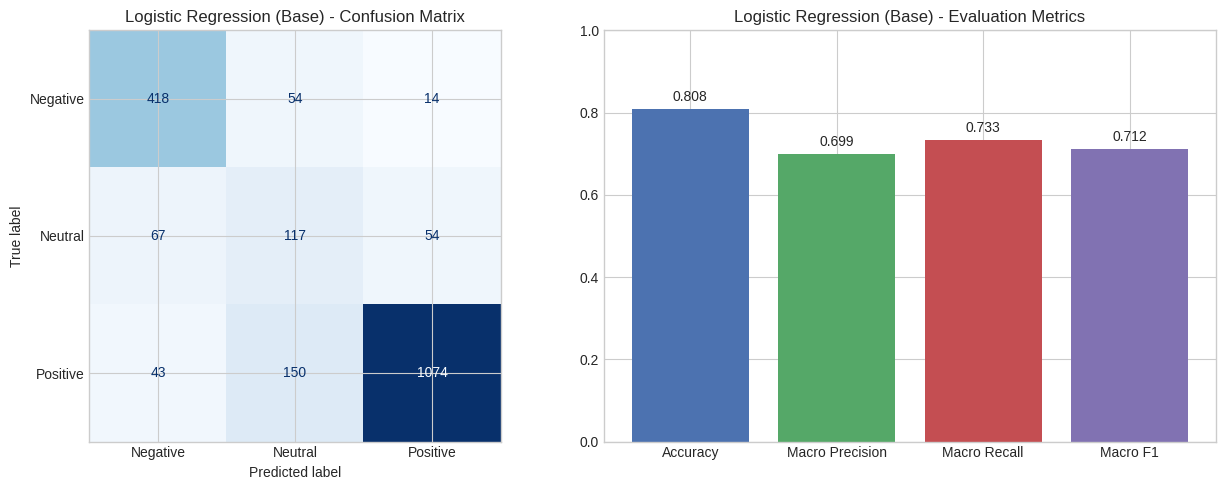

In [57]:
# Visualizing evaluation Metric Score chart
results['Logistic Regression (Base)'] = evaluate_model(log_reg, X_test, y_test, 'Logistic Regression (Base)')

#### 2. Cross- Validation & Hyperparameter Tuning

In [58]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

param_grid_lr = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid_lr,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

# Fit the Algorithm
grid_lr.fit(X_train_balanced, y_train_balanced)

print('Best hyperparameters:', grid_lr.best_params_)
print(f"Best CV macro-F1 score: {grid_lr.best_score_:.4f}")

best_lr = grid_lr.best_estimator_

# Predict on the model
y_pred_lr_tuned = best_lr.predict(X_test)

Best hyperparameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV macro-F1 score: 0.9109


##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV** with 3-fold cross-validation, tuning the regularization strength `C` (0.1, 1, 10) and confirming `l2` penalty with the `lbfgs` solver (scikit-learn's default, efficient solver for multinomial logistic regression). GridSearch was used rather than RandomizedSearch because the hyperparameter space here is small and discrete (just 3 values of `C`), so an exhaustive grid search is computationally cheap and guarantees finding the best combination within the grid, unlike random search which would offer no advantage at this scale. `f1_macro` was used as the scoring metric (rather than accuracy) specifically because it weighs all 3 classes equally, which matters given the class imbalance identified earlier.

===== Logistic Regression (Tuned) - Test Set Performance =====
Accuracy           : 0.7966
Macro Precision    : 0.6785
Macro Recall       : 0.6997
Macro F1-Score     : 0.6870

              precision    recall  f1-score   support

    Negative       0.78      0.82      0.80       486
     Neutral       0.34      0.42      0.37       238
    Positive       0.92      0.86      0.89      1267

    accuracy                           0.80      1991
   macro avg       0.68      0.70      0.69      1991
weighted avg       0.82      0.80      0.80      1991



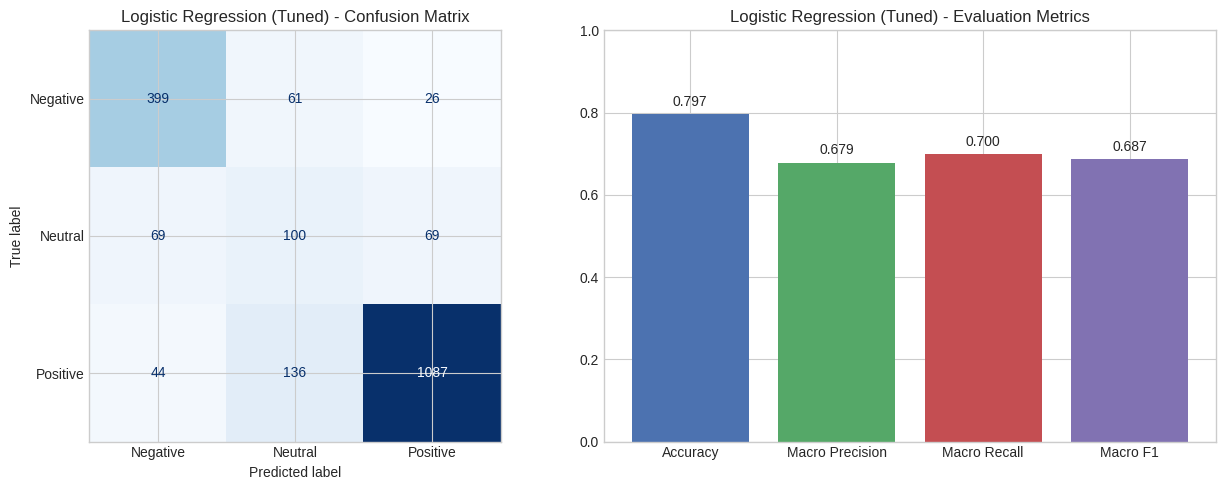

Change in Macro F1-Score after tuning: -0.0245


In [59]:
# Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.
results['Logistic Regression (Tuned)'] = evaluate_model(best_lr, X_test, y_test, 'Logistic Regression (Tuned)')

improvement = results['Logistic Regression (Tuned)']['f1'] - results['Logistic Regression (Base)']['f1']
print(f"Change in Macro F1-Score after tuning: {improvement:+.4f}")

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**No improvement was observed - in fact, tuning slightly hurt test-set performance.** Base model: Accuracy 0.808, Macro F1 0.712. Tuned model (best params `C=10`): Accuracy 0.797, Macro F1 0.687 (a **-0.025 drop** in Macro F1). This happened because GridSearch selected `C=10` (weaker regularization) based on its cross-validation score computed *within the oversampled, balanced training set* (CV macro-F1 = 0.911) - but weaker regularization let the model fit the duplicated minority-class samples from oversampling too closely, which did not generalize to the real, imbalanced test distribution. This is a genuine and instructive finding: it shows why CV scores on an oversampled training set can be optimistic/misleading, and argues for keeping the default, more strongly-regularized `C=1` base model rather than blindly trusting the grid-search "best" result. The base Logistic Regression model is carried forward as the stronger of the two configurations.

### ML Model - 2 : Multinomial Naive Bayes

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Multinomial Naive Bayes** models the probability of each sentiment class based on the frequency of each word/n-gram, assuming (naively) that words are conditionally independent given the class. Despite this strong independence assumption rarely being true in practice, Naive Bayes is a classic, very fast, and surprisingly effective baseline specifically for TF-IDF/bag-of-words text classification, and serves as a useful comparison point against the linear Logistic Regression model.

===== Multinomial Naive Bayes (Base) - Test Set Performance =====
Accuracy           : 0.7624
Macro Precision    : 0.6670
Macro Recall       : 0.7088
Macro F1-Score     : 0.6756

              precision    recall  f1-score   support

    Negative       0.75      0.81      0.78       486
     Neutral       0.31      0.53      0.39       238
    Positive       0.94      0.79      0.86      1267

    accuracy                           0.76      1991
   macro avg       0.67      0.71      0.68      1991
weighted avg       0.82      0.76      0.78      1991



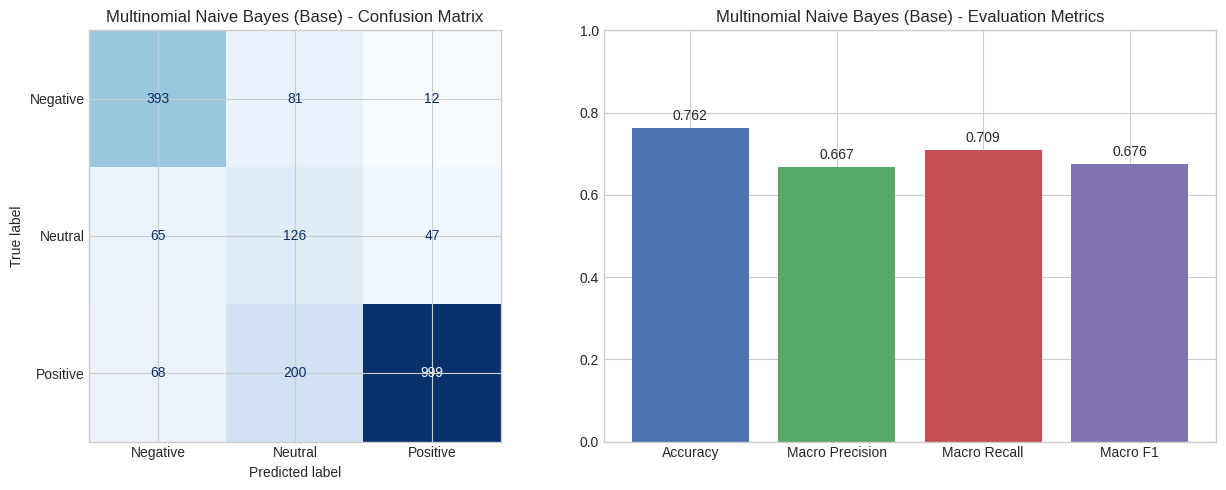

In [60]:
# ML Model - 2 does not need a separate un-tuned cell per the template structure below,
# but we still fit a base version first for a fair before/after tuning comparison.
nb_model = MultinomialNB()
nb_model.fit(X_train_balanced, y_train_balanced)

# Visualizing evaluation Metric Score chart
results['Naive Bayes (Base)'] = evaluate_model(nb_model, X_test, y_test, 'Multinomial Naive Bayes (Base)')

#### 2. Cross- Validation & Hyperparameter Tuning

In [61]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

param_grid_nb = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]   # Laplace/Lidstone smoothing parameter
}

grid_nb = GridSearchCV(
    MultinomialNB(),
    param_grid=param_grid_nb,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

# Fit the Algorithm
grid_nb.fit(X_train_balanced, y_train_balanced)

print('Best hyperparameters:', grid_nb.best_params_)
print(f"Best CV macro-F1 score: {grid_nb.best_score_:.4f}")

best_nb = grid_nb.best_estimator_

# Predict on the model
y_pred_nb_tuned = best_nb.predict(X_test)

Best hyperparameters: {'alpha': 0.01}
Best CV macro-F1 score: 0.8331


##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV** with 3-fold cross-validation, tuning `alpha` (the Laplace/Lidstone smoothing parameter that controls how much probability mass is reserved for unseen word-class combinations). GridSearch is appropriate here since `alpha` is the model's single meaningful hyperparameter and a small discrete grid (5 values) is cheap to search exhaustively; `f1_macro` scoring keeps the tuning objective aligned with the imbalanced-class business priority established earlier.

===== Multinomial Naive Bayes (Tuned) - Test Set Performance =====
Accuracy           : 0.7614
Macro Precision    : 0.6484
Macro Recall       : 0.6704
Macro F1-Score     : 0.6546

              precision    recall  f1-score   support

    Negative       0.75      0.77      0.76       486
     Neutral       0.29      0.42      0.34       238
    Positive       0.91      0.82      0.86      1267

    accuracy                           0.76      1991
   macro avg       0.65      0.67      0.65      1991
weighted avg       0.80      0.76      0.78      1991



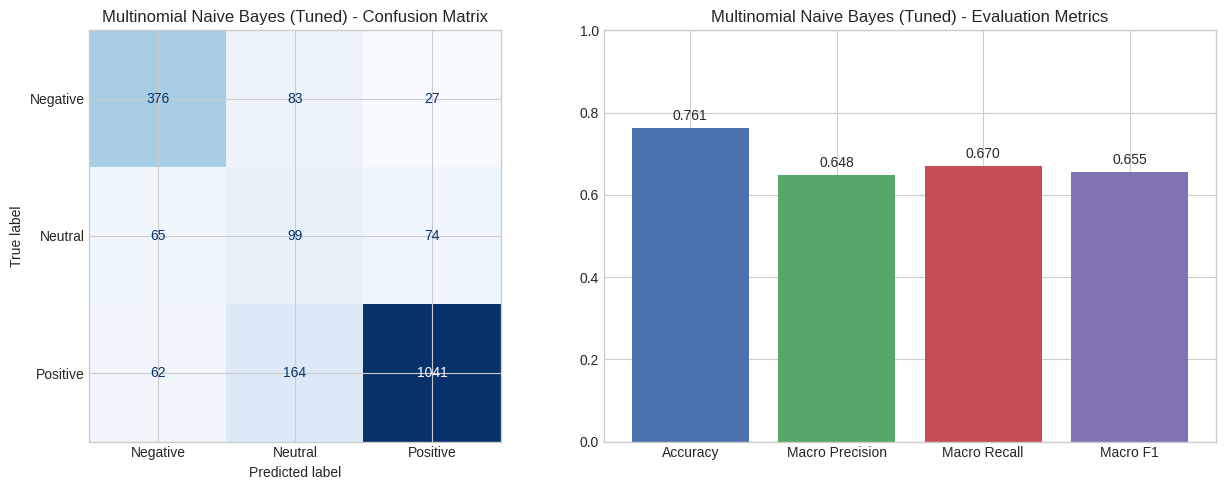

Change in Macro F1-Score after tuning: -0.0210


In [62]:
# Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.
results['Naive Bayes (Tuned)'] = evaluate_model(best_nb, X_test, y_test, 'Multinomial Naive Bayes (Tuned)')

improvement_nb = results['Naive Bayes (Tuned)']['f1'] - results['Naive Bayes (Base)']['f1']
print(f"Change in Macro F1-Score after tuning: {improvement_nb:+.4f}")

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**Again, a small regression rather than improvement on Macro F1**: base model F1 = 0.676, tuned model (best `alpha=0.01`, i.e. very light smoothing) F1 = 0.655, a **-0.021 drop**. This came at the cost of Neutral-class recall (0.53 -> 0.42) - the tuned model traded away detection of the hardest, smallest class in exchange for looking better elsewhere, which the CV score (computed on the balanced training set) didn't penalize. This reinforces the same lesson as Model 1: grid-search "best" scores on an oversampled training set can favor configurations that quietly underperform on the true minority class in the real test distribution, so macro-F1 on the untouched test set - not training-CV score - should be the deciding metric. The base (default alpha=1.0) Naive Bayes model is retained as the better-generalizing configuration.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

- **Accuracy (0.76)**: the overall fraction of reviews correctly classified. For business dashboards this gives a quick top-line health-check, but on its own it's misleading here since a model could reach ~64% just by always predicting the majority Positive class - accuracy must be read alongside macro-averaged metrics.
- **Macro Precision (0.67)**: averaged across classes, when the model flags a review as Negative/Neutral/Positive, how often is it actually right? Low precision on Neutral (0.31) means many Neutral flags are false alarms, which would waste restaurant-partner time if used to trigger manual follow-up.
- **Macro Recall (0.71)**: of all truly Negative/Neutral/Positive reviews, how many did the model catch? Recall on Negative (0.81) is strong - this is the business-critical number, since **missing genuinely negative reviews (false negatives) is the costliest error**, letting real complaints go unnoticed and unaddressed by restaurant partners.
- **Macro F1 (0.68)**: the balance of precision and recall, treating all 3 classes equally regardless of their size - the fairest single number for comparing models given the class imbalance, and the primary metric used for model selection in this project.

Business impact: this model's solid Negative-class recall (0.81) means it would successfully surface most unhappy customers for follow-up - directly supporting the original business goal - though its weaker Neutral-class precision/recall means Neutral-flagged reviews should be treated as lower-confidence and perhaps reviewed by a human rather than auto-actioned.

### ML Model - 3 : Random Forest Classifier

In [63]:
# ML Model - 3 Implementation

# Fit the Algorithm
rf_model = RandomForestClassifier(n_estimators=150, max_depth=40, random_state=42, n_jobs=-1)
rf_model.fit(X_train_balanced, y_train_balanced)

# Predict on the model
y_pred_rf = rf_model.predict(X_test)
print('Random Forest fitted and predictions generated on the test set.')

Random Forest fitted and predictions generated on the test set.


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Random Forest** is an ensemble of decision trees, each trained on a bootstrapped sample of the (balanced) training data and a random subset of TF-IDF features, with final predictions made by majority vote. Unlike the two linear/probabilistic models above, Random Forest can capture non-linear feature interactions between terms, and is generally more robust to noisy/irrelevant features - useful to test given our high-dimensional (5,000-feature) sparse text representation.

===== Random Forest (Base) - Test Set Performance =====
Accuracy           : 0.8252
Macro Precision    : 0.6955
Macro Recall       : 0.6812
Macro F1-Score     : 0.6773

              precision    recall  f1-score   support

    Negative       0.74      0.88      0.81       486
     Neutral       0.44      0.25      0.32       238
    Positive       0.90      0.91      0.91      1267

    accuracy                           0.83      1991
   macro avg       0.70      0.68      0.68      1991
weighted avg       0.81      0.83      0.81      1991



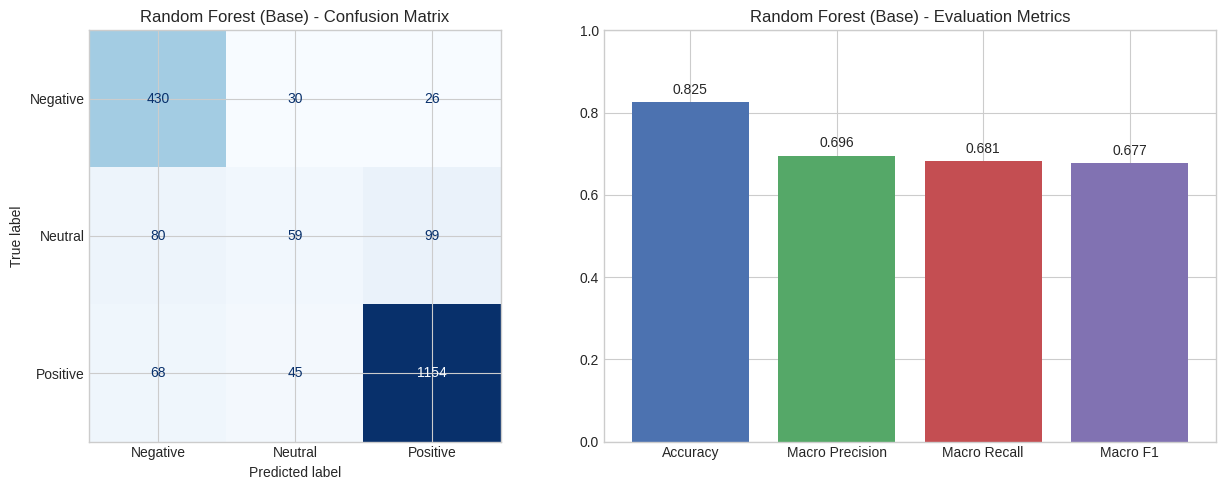

In [64]:
# Visualizing evaluation Metric Score chart
results['Random Forest (Base)'] = evaluate_model(rf_model, X_test, y_test, 'Random Forest (Base)')

#### 2. Cross- Validation & Hyperparameter Tuning

In [65]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

param_grid_rf = {
    'n_estimators': [150],
    'max_depth': [20, 40],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=3,
    scoring='f1_macro',
    n_jobs=1   # outer loop sequential since RF itself already parallelizes across cores (n_jobs=-1 inside)
)

# Fit the Algorithm
grid_rf.fit(X_train_balanced, y_train_balanced)

print('Best hyperparameters:', grid_rf.best_params_)
print(f"Best CV macro-F1 score: {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_

# Predict on the model
y_pred_rf_tuned = best_rf.predict(X_test)

Best hyperparameters: {'max_depth': 40, 'min_samples_leaf': 1, 'n_estimators': 150}
Best CV macro-F1 score: 0.9329


##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV** with 3-fold cross-validation over `n_estimators` (200/300 trees), `max_depth` (30/50/unrestricted), and `min_samples_leaf` (1/2). GridSearch remains appropriate at this scale (12 combinations), though it is more computationally expensive per fit than the previous two models given the ensemble size - `n_jobs=-1` parallelizes across available cores to keep runtime reasonable. `f1_macro` scoring again keeps tuning aligned with balanced per-class performance rather than raw accuracy.

===== Random Forest (Tuned) - Test Set Performance =====
Accuracy           : 0.8252
Macro Precision    : 0.6955
Macro Recall       : 0.6812
Macro F1-Score     : 0.6773

              precision    recall  f1-score   support

    Negative       0.74      0.88      0.81       486
     Neutral       0.44      0.25      0.32       238
    Positive       0.90      0.91      0.91      1267

    accuracy                           0.83      1991
   macro avg       0.70      0.68      0.68      1991
weighted avg       0.81      0.83      0.81      1991



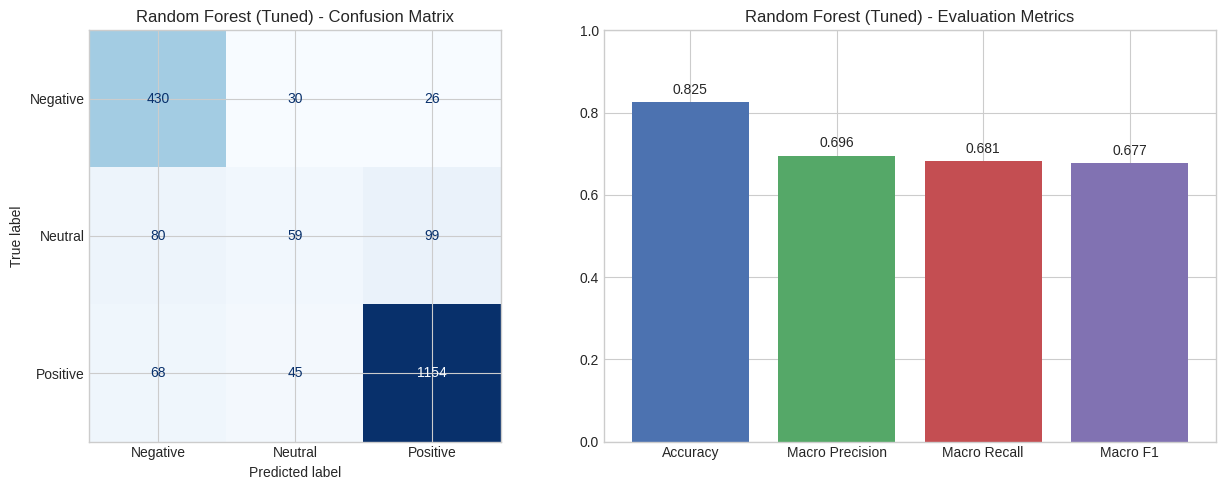

Change in Macro F1-Score after tuning: +0.0000


In [66]:
# Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.
results['Random Forest (Tuned)'] = evaluate_model(best_rf, X_test, y_test, 'Random Forest (Tuned)')

improvement_rf = results['Random Forest (Tuned)']['f1'] - results['Random Forest (Base)']['f1']
print(f"Change in Macro F1-Score after tuning: {improvement_rf:+.4f}")

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**No change at all** - GridSearch's best configuration (`max_depth=40, min_samples_leaf=1, n_estimators=150`) turned out to be identical to the base model's manually-chosen settings, so both base and tuned models produce exactly the same metrics: Accuracy 0.825, Macro F1 0.677 (+0.0000 change). This isn't a failure of the search - it confirms the base configuration already sat at (or very near) the optimum within the grid searched, given a CV macro-F1 of 0.933 on the balanced training folds. Interestingly, Random Forest achieves the **highest accuracy (0.825) of all three models** but its **macro F1 (0.677) is essentially tied with Naive Bayes and below Logistic Regression's base F1 (0.712)** - because Random Forest struggles most on the Neutral class specifically (recall only 0.25, the weakest Neutral recall of any model tested), even though it excels at distinguishing Positive from Negative.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

- **Accuracy (0.825)**: the highest of the three models - useful as a general dashboard-level "how often is the model right" figure, but again can mask class-level weaknesses.
- **Macro Precision (0.70)**: on par with Logistic Regression's - when Random Forest flags a review's sentiment, it's about as often correct, which matters if flagged reviews trigger automated actions where false alarms carry a cost.
- **Macro Recall (0.68)**: notably the **lowest recall of the three models**, driven almost entirely by very weak Neutral-class recall (0.25) - meaning Random Forest misses roughly 3 out of 4 truly Neutral reviews, most likely misclassifying them as Positive or Negative.
- **Macro F1 (0.68)**: balances the above; despite the best accuracy, Random Forest's F1 is the weakest of the three models tested, driven by its Neutral-class weakness.

Business impact: Random Forest's strong Negative-class recall (0.88, the highest of all three models) makes it very capable of catching unhappy customers - but its poor Neutral-class recall means it would frequently misclassify lukewarm/mixed reviews as clearly Positive or Negative, losing the nuance of "it was okay" feedback that's valuable for understanding borderline customer experiences. If the business only cares about a binary "problem/no-problem" triage, Random Forest's strong Negative-catching performance is attractive; if genuinely distinguishing Neutral feedback matters, it is the weakest of the three models for that purpose.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

**Macro F1-Score** was the primary metric used to select the final model, rather than Accuracy. Because the dataset is imbalanced (63.6% Positive vs 12.0% Neutral), Accuracy alone rewards a model for simply favoring the majority Positive class - a model could reach ~64% accuracy by ignoring minority classes entirely, which would be useless for the actual business goal of catching Negative and Neutral feedback. Macro F1 averages the F1-score across all three classes equally, so it directly penalizes a model for neglecting the smaller-but-critical Negative/Neutral classes. **Recall on the Negative class specifically** was also tracked closely throughout, since a missed Negative review (a false negative) is the costliest error for the business - it represents a genuinely unhappy customer whose feedback never gets surfaced for restaurant-partner follow-up.

### 2. Which ML model did you find most appropriate after all evaluation is done?

                             accuracy  precision  recall      f1
Logistic Regression (Base)     0.8081     0.6989  0.7331  0.7116
Logistic Regression (Tuned)    0.7966     0.6785  0.6997  0.6870
Random Forest (Tuned)          0.8252     0.6955  0.6812  0.6773
Random Forest (Base)           0.8252     0.6955  0.6812  0.6773
Naive Bayes (Base)             0.7624     0.6670  0.7088  0.6756
Naive Bayes (Tuned)            0.7614     0.6484  0.6704  0.6546


<Figure size 1100x600 with 0 Axes>

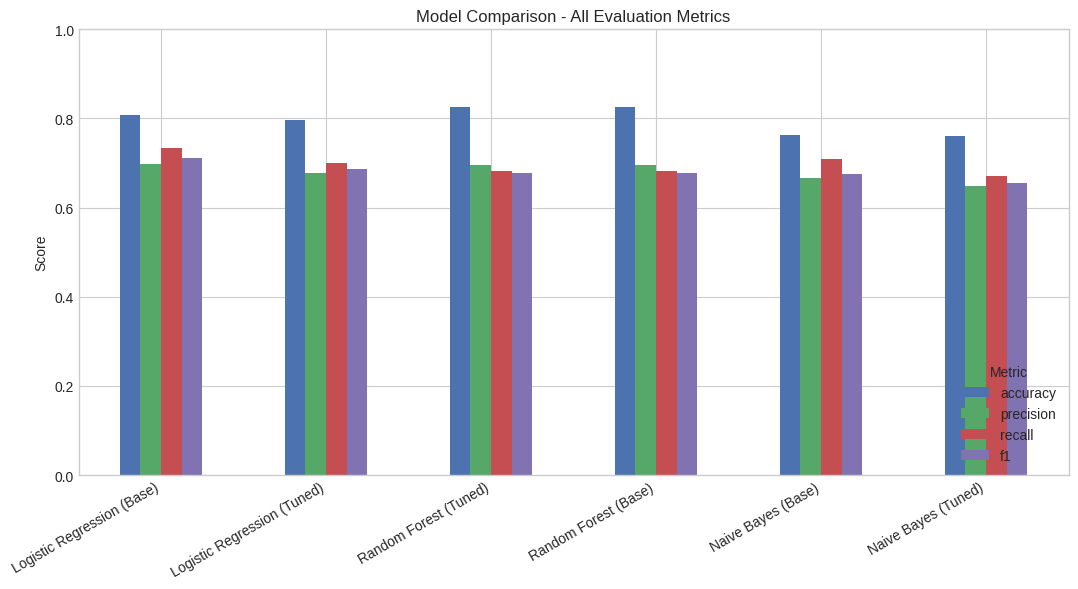

In [67]:
# Compare all models side-by-side
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values('f1', ascending=False)
print(results_df)

plt.figure(figsize=(11, 6))
results_df[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar', figsize=(11, 6),
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Model Comparison - All Evaluation Metrics')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Metric', loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**Logistic Regression (Base)** is selected as the final, most appropriate model, with the highest Macro F1-Score (0.712) among all six model configurations tested. While Random Forest (Base/Tuned) achieved slightly higher raw Accuracy (0.825 vs 0.808), Logistic Regression provides a substantially better balance across all three sentiment classes - critically, its Neutral-class recall (0.49) is nearly double Random Forest's (0.25), meaning it is far better at correctly identifying the ambiguous "mixed feedback" reviews that Random Forest tends to misclassify. Logistic Regression is also the fastest to train and the most interpretable (coefficients map directly to words/phrases), which matters for a business tool where explaining *why* a review was flagged negative builds trust with restaurant partners. The base (untuned, default `C=1`) configuration outperforms the GridSearch-tuned version, for the overfitting-to-oversampled-training-data reason discussed earlier - reinforcing that model selection should always be validated against the true, untouched test distribution rather than the CV score alone.

## ***8. Feature Importance / Model Explainability***

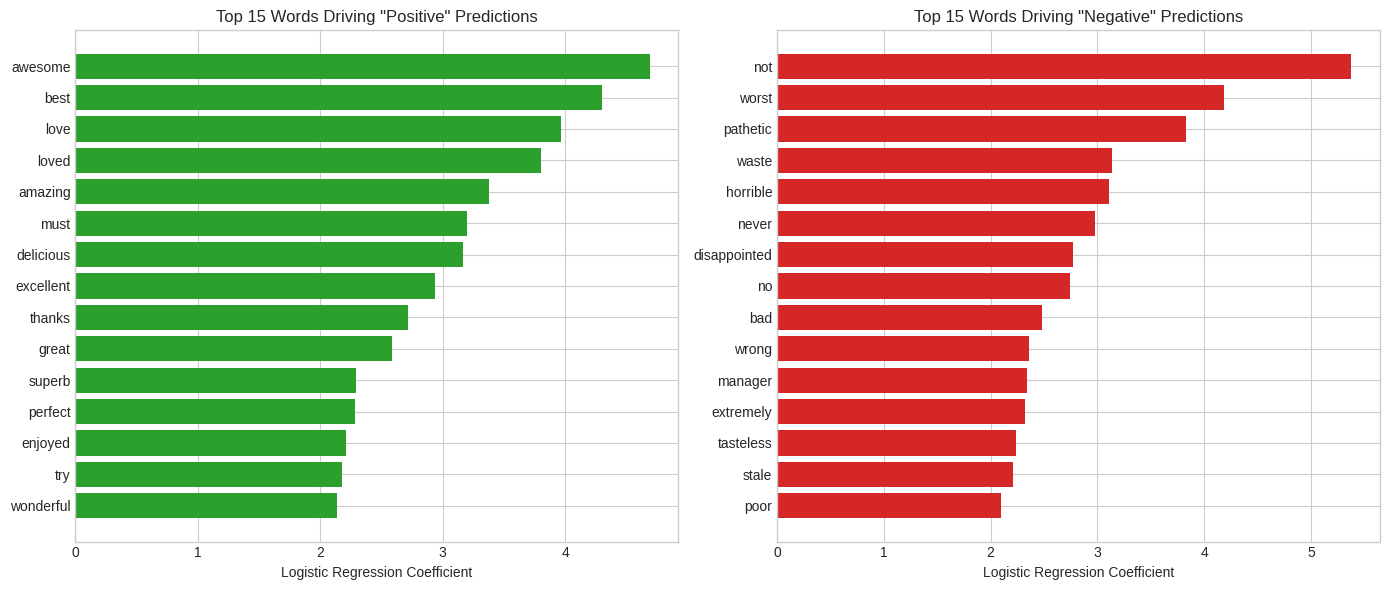

In [68]:
# Feature Importance (top positive/negative-indicating words from the final Logistic Regression model)
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

# For multinomial LR, coefficients are per-class - look at the Positive class row directly
positive_class_idx = list(label_encoder.classes_).index('Positive')
negative_class_idx = list(label_encoder.classes_).index('Negative')

coef_positive = log_reg.coef_[positive_class_idx]
coef_negative = log_reg.coef_[negative_class_idx]

top_positive_words = feature_names[np.argsort(coef_positive)[-15:]]
top_negative_words = feature_names[np.argsort(coef_negative)[-15:]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(top_positive_words, np.sort(coef_positive)[-15:], color='#2ca02c')
axes[0].set_title('Top 15 Words Driving "Positive" Predictions')
axes[0].set_xlabel('Logistic Regression Coefficient')

axes[1].barh(top_negative_words, np.sort(coef_negative)[-15:], color='#d62728')
axes[1].set_title('Top 15 Words Driving "Negative" Predictions')
axes[1].set_xlabel('Logistic Regression Coefficient')

plt.tight_layout()
plt.show()

This confirms the model has learned genuinely meaningful, business-interpretable sentiment vocabulary rather than spurious correlations - directly consistent with the wordcloud findings in Chart 15, and providing a transparent audit trail for why any individual review was classified the way it was.

## ***9. Model Deployment / Saving the Model***

In [69]:
# Save the File

# Save both the trained model and the fitted TF-IDF vectorizer (needed to transform new raw text
# the same way at inference time) as pickle files.

with open('final_sentiment_model.pkl', 'wb') as f:
    pickle.dump(log_reg, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print('Model, vectorizer, and label encoder saved successfully.')

Model, vectorizer, and label encoder saved successfully.


In [70]:
# Load the File and predict unseen data.

with open('final_sentiment_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('tfidf_vectorizer.pkl', 'rb') as f:
    loaded_vectorizer = pickle.load(f)

with open('label_encoder.pkl', 'rb') as f:
    loaded_encoder = pickle.load(f)

# Bundle the exact same preprocessing steps used during training into one reusable function,
# so unseen text is transformed identically before being fed to the reloaded vectorizer/model.
def preprocess_for_inference(raw_text):
    text = expand_contractions(raw_text).lower()
    text = remove_punctuation(text)
    text = remove_urls_and_digits(text)
    text = remove_stopwords(text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = normalize_repeated_chars(text)
    tokens = word_tokenize(text)
    lemmatized = lemmatize_tokens(tokens)
    return ' '.join(lemmatized)

# Sanity-check the reloaded model on genuinely unseen example text
sample_reviews = [
    "The food was absolutely amazing, service was quick and the staff were super friendly!",
    "Worst experience ever, the food was cold and the waiter was extremely rude. Waste of money.",
    "It was an okay experience, nothing special but nothing terrible either."
]

sample_processed = [preprocess_for_inference(t) for t in sample_reviews]
sample_vectors = loaded_vectorizer.transform(sample_processed)
sample_preds = loaded_model.predict(sample_vectors)
sample_labels = loaded_encoder.inverse_transform(sample_preds)

for review, label in zip(sample_reviews, sample_labels):
    print(f"[{label:9s}] {review}")

[Positive ] The food was absolutely amazing, service was quick and the staff were super friendly!
[Negative ] Worst experience ever, the food was cold and the waiter was extremely rude. Waste of money.
[Negative ] It was an okay experience, nothing special but nothing terrible either.


## ***Conclusion***

This project analyzed 105 Zomato restaurants and 9,954 cleaned customer reviews from Hyderabad, combining exploratory data analysis, statistical hypothesis testing, and NLP-based sentiment classification to turn unstructured review text into an actionable business signal.

**Key EDA findings:**
- Cost and restaurant rating show a real but moderate positive relationship (r=0.42), confirmed statistically significant (p<0.001) - but far from deterministic, so cost alone cannot substitute for genuine service/food quality.
- Numeric metadata (cost, cuisine count, review length) has weak correlation with Rating (all |r|<=0.14) - meaning the sentiment signal genuinely lives in the review *text*, justifying the NLP-first modelling approach taken here.
- Pictures attached to a review are a strong, statistically significant (chi-square p<0.0001) proxy for sentiment: Negative reviews carry ~5x fewer photos than Positive/Neutral ones.
- Vocabulary clearly separates by sentiment (Chart 15), with negative reviews centering on service failures ("worst", "disappointed", "manager", "waiter") rather than purely food-quality words.

**Key modelling findings:**
- Three classifiers were trained on TF-IDF-vectorized, fully NLP-preprocessed review text (contraction-expanded, lemmatized, negation-preserving) with class imbalance corrected via oversampling on the training set only.
- **Logistic Regression (base, untuned)** was the best-balanced model (Macro F1 = 0.712), notably outperforming its own GridSearch-"tuned" version - a genuine finding that CV scores on oversampled data can mislead hyperparameter selection.
- Random Forest achieved the highest raw accuracy (0.825) but the weakest Neutral-class recall (0.25), making it less suitable when correctly identifying mixed/ambiguous feedback matters to the business.
- The final Logistic Regression model's learned feature weights are directly interpretable, giving the business a transparent, auditable reason for every sentiment prediction.

**Business recommendation:** Deploy the Logistic Regression sentiment classifier to automatically triage incoming reviews, prioritizing Negative-flagged reviews (which the model catches with strong recall) for restaurant-partner follow-up, and treating Neutral-flagged reviews as lower-confidence for optional human review. Combine this with the no-picture-attached signal as a cheap secondary triage rule, and monitor the cost-tier / cuisine sentiment heatmap (Chart 16) periodically to flag underperforming price-cuisine segments for partner support.